## Como Ler Este Volume

1. Visão geral do projeto.
2. Contexto metodológico e bases utilizadas.
3. Construção da base integrada e organização dos arquivos principais.
4. Resultados, comparações e visualizações.
5. Dicionário de dados e validação dos arquivos finais.
6. Apêndice técnico com benchmark de formatos de armazenamento.
7. Apêndice documental com síntese das validações do projeto.


## 2. Contexto do Estudo

Este projeto foi organizado como um estudo **quantitativo, aplicado, descritivo e exploratorio**. O foco esta em integrar bases publicas, organizar os dados com cuidado e interpretar padroes observados nos municipios brasileiros.

A base do trabalho articula populacao municipal, PAM, PPM, Censo Agropecuario e indicadores educacionais rurais. A integracao e feita com `codigo_municipio` de 7 digitos, e o recorte `Rural` permanece explicito no bloco educacional.

Nesta versao, o eixo metodologico foi ajustado para reconhecer **observabilidade desigual entre dimensoes**. Em termos praticos, ausencia estrutural de base educacional rural nao e tratada como abandono zero, e a leitura territorial separa limitacao de aplicabilidade de insuficiencia residual.

## 3. Base Integrada e Preparacao dos Dados

A seguir esta o nucleo operacional do projeto: leitura da base longa, reconstrucao do snapshot analitico, revalidacao focal do bloco educacional com insumos locais e exportacao dos artefatos finais atualizados.

In [1]:
from __future__ import annotations

import io
import os
import unicodedata
import warnings
import zipfile
from dataclasses import dataclass
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

REGIME_VALUES = [
    "intensificacao_com_esvaziamento_e_fragilidade",
    "intensificacao_com_esvaziamento_sem_fragilidade_observada",
    "intensificacao_com_fragilidade_educacional",
    "intensificacao_com_adaptacao_relativa",
    "esvaziamento_demografico_com_fragilidade_educacional",
    "esvaziamento_demografico_sem_intensificacao",
    "fragilidade_educacional_sem_pressao_agropecuaria",
    "baixa_pressao_territorial",
    "insuficiencia_educacional_inconsistente",
    "insuficiencia_demografica_residual",
]
SUBDOMINIOS_CENTRAIS = {
    "populacao_municipal",
    "pam_area_colhida",
    "ppm_rebanhos",
    "censo_agro_estrutura",
    "censo_agro_mecanizacao",
    "matriculas_ensino_medio",
    "rendimento_escolar",
}
SNAPSHOT_COLUNAS_CENTRAIS = {
    "taxa_abandono_rural_2024",
    "matriculas_ensino_medio_rural_2024",
    "flag_abandono_rural_aplicavel",
    "grau_completude_analitica",
    "motivo_dados_insuficientes",
    "regime_territorial",
}
METRICAS_DESCRITIVAS = [
    "populacao_total_2024",
    "area_total_culturas_selecionadas_hectares_2024",
    "efetivo_bovino_2024",
    "matriculas_ensino_medio_rural_2024",
    "taxa_abandono_rural_2024",
    "escore_intensificacao_agropecuaria_2024",
]
PAM_PRODUTOS = {
    "Algodao herbaceo (em caroco)": "area_algodao_hectares",
    "Cana-de-acucar": "area_cana_hectares",
    "Milho (em grao)": "area_milho_hectares",
    "Soja (em grao)": "area_soja_hectares",
}
SNAPSHOT_COLUMNS = [
    "codigo_municipio",
    "nome_municipio",
    "sigla_estado",
    "regiao",
    "populacao_total_2010",
    "populacao_total_2024",
    "area_algodao_hectares_2010",
    "area_algodao_hectares_2024",
    "area_cana_hectares_2010",
    "area_cana_hectares_2024",
    "area_milho_hectares_2010",
    "area_milho_hectares_2024",
    "area_soja_hectares_2010",
    "area_soja_hectares_2024",
    "efetivo_bovino_2010",
    "efetivo_bovino_2024",
    "total_estabelecimentos_agricolas_2017",
    "area_total_agricola_hectares_2017",
    "num_tratores_2017",
    "matriculas_ensino_medio_rural_2024",
    "taxa_abandono_rural_2024",
    "flag_abandono_rural_aplicavel",
    "flag_lacuna_educacional_estrutural",
    "flag_lacuna_educacional_inconsistente",
    "flag_lacuna_tratores",
    "motivo_dados_insuficientes",
    "grau_completude_analitica",
    "area_total_culturas_selecionadas_hectares_2024",
    "variacao_populacao_2010_2024_pct",
    "variacao_area_soja_2010_2024_pct",
    "variacao_area_milho_2010_2024_pct",
    "variacao_area_cana_2010_2024_pct",
    "variacao_rebanho_bovino_2010_2024_pct",
    "tratores_por_100_estabelecimentos_2017",
    "hectares_por_estabelecimento_2017",
    "matriculas_rurais_por_1000_hab_2024",
    "percentil_area_culturas_2024",
    "percentil_bovino_2024",
    "escore_intensificacao_agropecuaria_2024",
    "quartil_intensificacao_agropecuaria",
    "porte_populacional_2024",
    "sinal_intensificacao_agropecuaria",
    "sinal_esvaziamento_demografico",
    "sinal_fragilidade_educacional",
    "regime_territorial",
]


@dataclass
class PipelineArtifacts:
    configuracao: pd.DataFrame
    checkpoints_etl: pd.DataFrame
    base_longa: pd.DataFrame
    snapshot_analitico: pd.DataFrame
    validacoes: pd.DataFrame
    revisao_amostral: pd.DataFrame
    resumo_exportacao: pd.DataFrame
    auditoria_completude: pd.DataFrame
    auditoria_insuficiencia: pd.DataFrame
    inconsistencias_educacionais: pd.DataFrame
    tabela_descritiva: pd.DataFrame
    comparacao_quartis: pd.DataFrame
    comparacao_regiao: pd.DataFrame
    comparacao_porte: pd.DataFrame
    resumo_regimes: pd.DataFrame
    matriz_correlacao: pd.DataFrame
    municipios_destaque_regime: pd.DataFrame
    conclusao_markdown: str
    long_output_path: Path
    analytic_output_path: Path
    inconsistencias_output_path: Path



def descobrir_raiz_projeto() -> Path:
    candidatos = [Path.cwd().resolve(), Path.cwd().resolve().parent]
    for candidato in candidatos:
        if (candidato / "dados").exists() and (candidato / "notebooks").exists():
            return candidato
    raise FileNotFoundError("Nao foi possivel localizar a raiz do projeto.")


PROJECT_ROOT = descobrir_raiz_projeto()
LONG_OUTPUT = PROJECT_ROOT / "dados" / "saidas_finais" / "master_municipios_longo.csv"
ANALYTIC_OUTPUT = PROJECT_ROOT / "dados" / "saidas_finais" / "master_municipios_analitico_snapshot.csv"
INCONSISTENCIAS_OUTPUT = PROJECT_ROOT / "dados" / "saidas_finais" / "inconsistencias_educacionais_residuais.csv"
RAW_MATRICULAS_PATH = PROJECT_ROOT / "dados" / "Sinopse_Estatistica_da_Educação_Basica_2024.xlsx"
RAW_RENDIMENTO_PATH = PROJECT_ROOT / "dados" / "tx_rend_municipios_2024.zip"
VOLUME_PATH = PROJECT_ROOT / "notebooks" / "PAD_projeto.ipynb"



def carregar_csv_obrigatorio(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Arquivo nao encontrado: {path}")
    return pd.read_csv(path, low_memory=False)



def normalizar_codigo_ibge(series: pd.Series) -> pd.Series:
    return (
        series.astype("string")
        .str.strip()
        .str.replace(".0", "", regex=False)
        .str.extract(r"(\d+)", expand=False)
        .str.zfill(7)
    )



def limpar_texto(value: object) -> str | pd.NA:
    if pd.isna(value):
        return pd.NA
    return str(value).strip()



def normalizar_rotulo(value: object) -> str:
    if pd.isna(value):
        return ""
    texto = unicodedata.normalize("NFKD", str(value))
    texto = texto.encode("ascii", "ignore").decode("ascii")
    return " ".join(texto.split()).strip()



def flatten_multilevel_label(column: tuple[object, ...]) -> str:
    partes = [normalizar_rotulo(item) for item in column if isinstance(item, str) and normalizar_rotulo(item)]
    return " | ".join(partes)



def plotar_barras(series: pd.Series, title: str, ylabel: str) -> None:
    plot_series = pd.Series(series).fillna(0)
    plt.figure(figsize=(10, 4))
    plot_series.plot(kind="bar", color="#4daf4a")
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()



def formatar_agregacao(dataframe: pd.DataFrame, group_col: str) -> pd.DataFrame:
    agregado = (
        dataframe.dropna(subset=[group_col])
        .groupby(group_col)
        .agg(
            municipios=("codigo_municipio", "nunique"),
            populacao_media_2024=("populacao_total_2024", "mean"),
            area_culturas_media_2024=("area_total_culturas_selecionadas_hectares_2024", "mean"),
            efetivo_bovino_medio_2024=("efetivo_bovino_2024", "mean"),
            abandono_medio_2024=("taxa_abandono_rural_2024", "mean"),
            escore_agro_medio_2024=("escore_intensificacao_agropecuaria_2024", "mean"),
        )
        .reset_index()
    )
    for col in agregado.columns:
        if col != group_col and pd.api.types.is_numeric_dtype(agregado[col]):
            agregado[col] = agregado[col].round(2)
    return agregado



def construir_lookup(base_longa: pd.DataFrame) -> pd.DataFrame:
    return (
        base_longa[["codigo_municipio", "nome_municipio", "sigla_estado", "regiao"]]
        .drop_duplicates(subset=["codigo_municipio"])
        .sort_values("codigo_municipio")
        .reset_index(drop=True)
    )



def extrair_da_base_longa(
    dataframe: pd.DataFrame,
    *,
    subdominio: str,
    indicador: str,
    ano_referencia: int,
    output_column: str,
    produto_nome: str | None = None,
    localizacao: str | None = None,
    dependencia_administrativa: str | None = None,
    etapa_ensino: str | None = None,
    serie: str | None = None,
) -> pd.DataFrame:
    mask = dataframe["subdominio"].astype("string").eq(subdominio)
    mask &= dataframe["indicador"].astype("string").eq(indicador)
    mask &= dataframe["ano_referencia"].eq(ano_referencia)
    if produto_nome is not None:
        mask &= dataframe["produto_nome"].astype("string").eq(produto_nome)
    if localizacao is not None:
        mask &= dataframe["localizacao"].astype("string").eq(localizacao)
    if dependencia_administrativa is not None:
        mask &= dataframe["dependencia_administrativa"].astype("string").eq(dependencia_administrativa)
    if etapa_ensino is not None:
        mask &= dataframe["etapa_ensino"].astype("string").eq(etapa_ensino)
    if serie is not None:
        mask &= dataframe["serie"].astype("string").eq(serie)

    selecionado = dataframe.loc[mask, ["codigo_municipio", "valor"]].copy()
    if selecionado["codigo_municipio"].duplicated().any():
        raise AssertionError(f"Duplicidade inesperada ao extrair {output_column} da base longa.")
    return selecionado.rename(columns={"valor": output_column})



def carregar_matriculas_rurais_raw(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Arquivo nao encontrado: {path}")

    frame = pd.read_excel(path, sheet_name="1.26", header=[5, 6, 7, 8])
    colunas = []
    for column in frame.columns:
        if isinstance(column, tuple):
            code = str(column[-1]).strip()
            if code == "Unnamed: 0_level_3":
                colunas.append("regiao_inep")
            elif code == "Unnamed: 1_level_3":
                colunas.append("uf_extenso")
            elif code == "Unnamed: 2_level_3":
                colunas.append("nome_municipio_inep")
            elif code == "Unnamed: 3_level_3":
                colunas.append("codigo_municipio")
            else:
                colunas.append(flatten_multilevel_label(column))
        else:
            colunas.append(str(column))
    frame.columns = colunas

    coluna_rural_total = next(
        (
            coluna
            for coluna in frame.columns
            if str(coluna).startswith("Numero de Matriculas do Ensino Medio")
            and "Rural" in str(coluna)
            and str(coluna).endswith("Total")
        ),
        None,
    )
    if coluna_rural_total is None:
        raise KeyError("Nao foi possivel localizar a coluna de matriculas rurais no arquivo bruto do INEP.")

    resultado = frame[["codigo_municipio", coluna_rural_total]].copy()
    resultado["codigo_municipio"] = normalizar_codigo_ibge(resultado["codigo_municipio"])
    resultado = resultado[resultado["codigo_municipio"].notna()].copy()
    resultado[coluna_rural_total] = pd.to_numeric(resultado[coluna_rural_total], errors="coerce")
    return resultado.rename(columns={coluna_rural_total: "matriculas_ensino_medio_rural_2024_raw"})



def carregar_abandono_rural_raw(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Arquivo nao encontrado: {path}")

    with zipfile.ZipFile(path) as zipped:
        excel_name = next((name for name in zipped.namelist() if name.endswith(".xlsx")), None)
        if excel_name is None:
            raise FileNotFoundError("Nenhum arquivo .xlsx foi encontrado no zip de rendimento escolar.")
        payload = io.BytesIO(zipped.read(excel_name))

    frame = pd.read_excel(payload, sheet_name="MUNICIPIOS ", header=[5, 6, 7, 8])
    metadata = {}
    flat_columns = []
    for column in frame.columns:
        if isinstance(column, tuple):
            code = str(column[-1]).strip()
            flat_columns.append(code)
            if code.startswith(("1_", "2_", "3_")):
                indicador = normalizar_rotulo(column[0])
                etapa = normalizar_rotulo(column[1])
                serie = (
                    normalizar_rotulo(column[2])
                    .replace(" ", "_")
                    .replace("-", "_")
                    .lower()
                    .replace("__", "_")
                )
                if indicador == "Taxa de Abandono" and etapa == "Ensino Medio":
                    metadata[code] = {
                        "indicador": "taxa_abandono",
                        "etapa_ensino": "ensino_medio",
                        "serie": serie,
                    }
        else:
            flat_columns.append(str(column))
    frame.columns = flat_columns
    frame = frame.rename(
        columns={
            "CO_MUNICIPIO": "codigo_municipio",
            "NO_CATEGORIA": "localizacao",
            "NO_DEPENDENCIA": "dependencia_administrativa",
        }
    )
    frame["codigo_municipio"] = normalizar_codigo_ibge(frame["codigo_municipio"])
    frame = frame[frame["codigo_municipio"].notna()].copy()
    frame["localizacao"] = frame["localizacao"].map(limpar_texto)
    frame["dependencia_administrativa"] = frame["dependencia_administrativa"].map(limpar_texto)

    measure_columns = [column for column in frame.columns if str(column).startswith(("1_", "2_", "3_"))]
    melted = frame.melt(
        id_vars=["codigo_municipio", "localizacao", "dependencia_administrativa"],
        value_vars=measure_columns,
        var_name="medida",
        value_name="valor",
    )
    metadata_frame = pd.DataFrame.from_dict(metadata, orient="index").rename_axis("medida").reset_index()
    melted = melted.merge(metadata_frame, on="medida", how="left")
    melted["valor"] = pd.to_numeric(
        melted["valor"].astype("string").str.replace("--", "", regex=False).str.replace(",", ".", regex=False),
        errors="coerce",
    )

    resultado = melted[
        (melted["indicador"] == "taxa_abandono")
        & (melted["etapa_ensino"] == "ensino_medio")
        & (melted["serie"] == "total")
        & (melted["localizacao"] == "Rural")
        & (melted["dependencia_administrativa"] == "Total")
    ][["codigo_municipio", "valor"]].copy()
    return resultado.rename(columns={"valor": "taxa_abandono_rural_2024_raw"})



def calcular_variacao_pct(valor_novo: pd.Series, valor_antigo: pd.Series) -> pd.Series:
    base = valor_antigo.replace(0, np.nan)
    return ((valor_novo - base) / base) * 100



def calcular_percentil(series: pd.Series) -> pd.Series:
    return series.rank(pct=True, method="average")



def categorizar_porte_populacional(series: pd.Series) -> pd.Series:
    return pd.cut(
        series,
        bins=[-np.inf, 10000, 50000, 200000, np.inf],
        labels=["ate_10_mil", "10_a_50_mil", "50_a_200_mil", "acima_200_mil"],
    )



def construir_snapshot_analitico_revisado(base_longa: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    lookup = construir_lookup(base_longa)
    snapshot = lookup.copy()

    snapshot = snapshot.merge(
        extrair_da_base_longa(
            base_longa,
            subdominio="populacao_municipal",
            indicador="populacao_total",
            ano_referencia=2010,
            output_column="populacao_total_2010",
        ),
        on="codigo_municipio",
        how="left",
    )
    snapshot = snapshot.merge(
        extrair_da_base_longa(
            base_longa,
            subdominio="populacao_municipal",
            indicador="populacao_total",
            ano_referencia=2024,
            output_column="populacao_total_2024",
        ),
        on="codigo_municipio",
        how="left",
    )

    for produto_nome, prefixo in PAM_PRODUTOS.items():
        for ano in [2010, 2024]:
            snapshot = snapshot.merge(
                extrair_da_base_longa(
                    base_longa,
                    subdominio="pam_area_colhida",
                    indicador="area_colhida",
                    ano_referencia=ano,
                    produto_nome=produto_nome,
                    output_column=f"{prefixo}_{ano}",
                ),
                on="codigo_municipio",
                how="left",
            )

    snapshot = snapshot.merge(
        extrair_da_base_longa(
            base_longa,
            subdominio="ppm_rebanhos",
            indicador="efetivo_rebanho",
            ano_referencia=2010,
            produto_nome="Bovino",
            output_column="efetivo_bovino_2010",
        ),
        on="codigo_municipio",
        how="left",
    )
    snapshot = snapshot.merge(
        extrair_da_base_longa(
            base_longa,
            subdominio="ppm_rebanhos",
            indicador="efetivo_rebanho",
            ano_referencia=2024,
            produto_nome="Bovino",
            output_column="efetivo_bovino_2024",
        ),
        on="codigo_municipio",
        how="left",
    )
    snapshot = snapshot.merge(
        extrair_da_base_longa(
            base_longa,
            subdominio="censo_agro_estrutura",
            indicador="numero_estabelecimentos_agropecuarios",
            ano_referencia=2017,
            output_column="total_estabelecimentos_agricolas_2017",
        ),
        on="codigo_municipio",
        how="left",
    )
    snapshot = snapshot.merge(
        extrair_da_base_longa(
            base_longa,
            subdominio="censo_agro_estrutura",
            indicador="area_estabelecimentos_agropecuarios",
            ano_referencia=2017,
            output_column="area_total_agricola_hectares_2017",
        ),
        on="codigo_municipio",
        how="left",
    )
    snapshot = snapshot.merge(
        extrair_da_base_longa(
            base_longa,
            subdominio="censo_agro_mecanizacao",
            indicador="numero_tratores",
            ano_referencia=2017,
            output_column="num_tratores_2017",
        ),
        on="codigo_municipio",
        how="left",
    )
    snapshot = snapshot.merge(
        extrair_da_base_longa(
            base_longa,
            subdominio="matriculas_ensino_medio",
            indicador="matriculas",
            ano_referencia=2024,
            localizacao="Rural",
            dependencia_administrativa="Total",
            output_column="matriculas_ensino_medio_rural_2024",
        ),
        on="codigo_municipio",
        how="left",
    )
    snapshot = snapshot.merge(
        extrair_da_base_longa(
            base_longa,
            subdominio="rendimento_escolar",
            indicador="taxa_abandono",
            ano_referencia=2024,
            localizacao="Rural",
            dependencia_administrativa="Total",
            etapa_ensino="ensino_medio",
            serie="total",
            output_column="taxa_abandono_rural_2024",
        ),
        on="codigo_municipio",
        how="left",
    )

    matriculas_raw = carregar_matriculas_rurais_raw(RAW_MATRICULAS_PATH)
    abandono_raw = carregar_abandono_rural_raw(RAW_RENDIMENTO_PATH)
    snapshot = snapshot.merge(matriculas_raw, on="codigo_municipio", how="left")
    snapshot = snapshot.merge(abandono_raw, on="codigo_municipio", how="left")

    inconsistencias = []
    for coluna, coluna_raw in [
        ("matriculas_ensino_medio_rural_2024", "matriculas_ensino_medio_rural_2024_raw"),
        ("taxa_abandono_rural_2024", "taxa_abandono_rural_2024_raw"),
    ]:
        snapshot[coluna] = pd.to_numeric(snapshot[coluna], errors="coerce")
        snapshot[coluna_raw] = pd.to_numeric(snapshot[coluna_raw], errors="coerce")

        precisa_preencher = snapshot[coluna].isna() & snapshot[coluna_raw].notna()
        snapshot.loc[precisa_preencher, coluna] = snapshot.loc[precisa_preencher, coluna_raw]

        conflito = snapshot[coluna].notna() & snapshot[coluna_raw].notna() & (~np.isclose(snapshot[coluna], snapshot[coluna_raw], equal_nan=True))
        if conflito.any():
            inconsistencias.append(
                snapshot.loc[
                    conflito,
                    ["codigo_municipio", "nome_municipio", "sigla_estado", coluna, coluna_raw],
                ]
                .rename(columns={coluna: "valor_snapshot_original", coluna_raw: "valor_fonte_bruta"})
                .assign(variavel=coluna, acao_aplicada="fonte_bruta_priorizada")
            )
            snapshot.loc[conflito, coluna] = snapshot.loc[conflito, coluna_raw]

    inconsistencias_df = (
        pd.concat(inconsistencias, ignore_index=True)
        if inconsistencias
        else pd.DataFrame(
            columns=[
                "codigo_municipio",
                "nome_municipio",
                "sigla_estado",
                "valor_snapshot_original",
                "valor_fonte_bruta",
                "variavel",
                "acao_aplicada",
            ]
        )
    )

    for coluna in [
        "area_algodao_hectares_2010",
        "area_algodao_hectares_2024",
        "area_cana_hectares_2010",
        "area_cana_hectares_2024",
        "area_milho_hectares_2010",
        "area_milho_hectares_2024",
        "area_soja_hectares_2010",
        "area_soja_hectares_2024",
        "efetivo_bovino_2010",
        "efetivo_bovino_2024",
    ]:
        snapshot[coluna] = pd.to_numeric(snapshot[coluna], errors="coerce").fillna(0)

    for coluna in [
        "populacao_total_2010",
        "populacao_total_2024",
        "total_estabelecimentos_agricolas_2017",
        "area_total_agricola_hectares_2017",
        "num_tratores_2017",
        "matriculas_ensino_medio_rural_2024",
        "taxa_abandono_rural_2024",
    ]:
        snapshot[coluna] = pd.to_numeric(snapshot[coluna], errors="coerce")

    snapshot["area_total_culturas_selecionadas_hectares_2024"] = snapshot[[f"{prefixo}_2024" for prefixo in PAM_PRODUTOS.values()]].sum(axis=1)
    snapshot["variacao_populacao_2010_2024_pct"] = calcular_variacao_pct(snapshot["populacao_total_2024"], snapshot["populacao_total_2010"])
    snapshot["variacao_area_soja_2010_2024_pct"] = calcular_variacao_pct(snapshot["area_soja_hectares_2024"], snapshot["area_soja_hectares_2010"])
    snapshot["variacao_area_milho_2010_2024_pct"] = calcular_variacao_pct(snapshot["area_milho_hectares_2024"], snapshot["area_milho_hectares_2010"])
    snapshot["variacao_area_cana_2010_2024_pct"] = calcular_variacao_pct(snapshot["area_cana_hectares_2024"], snapshot["area_cana_hectares_2010"])
    snapshot["variacao_rebanho_bovino_2010_2024_pct"] = calcular_variacao_pct(snapshot["efetivo_bovino_2024"], snapshot["efetivo_bovino_2010"])
    snapshot["tratores_por_100_estabelecimentos_2017"] = (
        snapshot["num_tratores_2017"] / snapshot["total_estabelecimentos_agricolas_2017"].replace(0, np.nan)
    ) * 100
    snapshot["hectares_por_estabelecimento_2017"] = (
        snapshot["area_total_agricola_hectares_2017"] / snapshot["total_estabelecimentos_agricolas_2017"].replace(0, np.nan)
    )
    snapshot["matriculas_rurais_por_1000_hab_2024"] = (
        snapshot["matriculas_ensino_medio_rural_2024"] / snapshot["populacao_total_2024"].replace(0, np.nan)
    ) * 1000
    snapshot["percentil_area_culturas_2024"] = calcular_percentil(snapshot["area_total_culturas_selecionadas_hectares_2024"])
    snapshot["percentil_bovino_2024"] = calcular_percentil(snapshot["efetivo_bovino_2024"])
    snapshot["escore_intensificacao_agropecuaria_2024"] = (
        snapshot["percentil_area_culturas_2024"] + snapshot["percentil_bovino_2024"]
    ) / 2
    snapshot["quartil_intensificacao_agropecuaria"] = pd.qcut(
        snapshot["escore_intensificacao_agropecuaria_2024"].rank(method="first"),
        4,
        labels=["Q1", "Q2", "Q3", "Q4"],
    )
    snapshot["porte_populacional_2024"] = categorizar_porte_populacional(snapshot["populacao_total_2024"])

    snapshot["flag_abandono_rural_aplicavel"] = snapshot["matriculas_ensino_medio_rural_2024"].fillna(0).gt(0)
    snapshot["flag_lacuna_educacional_estrutural"] = (~snapshot["flag_abandono_rural_aplicavel"]) & snapshot["taxa_abandono_rural_2024"].isna()
    snapshot["flag_lacuna_educacional_inconsistente"] = snapshot["flag_abandono_rural_aplicavel"] & snapshot["taxa_abandono_rural_2024"].isna()
    snapshot["flag_lacuna_tratores"] = snapshot["num_tratores_2017"].isna()

    inconsistencias_residuais = (
        snapshot.loc[
            snapshot["flag_lacuna_educacional_inconsistente"],
            [
                "codigo_municipio",
                "nome_municipio",
                "sigla_estado",
                "taxa_abandono_rural_2024",
            ],
        ]
        .rename(columns={"taxa_abandono_rural_2024": "valor_snapshot_original"})
        .assign(
            valor_fonte_bruta=pd.NA,
            variavel="taxa_abandono_rural_2024",
            acao_aplicada="registrar_para_revisao",
        )
    )
    inconsistencias_df = pd.concat(
        [inconsistencias_df, inconsistencias_residuais],
        ignore_index=True,
    ).drop_duplicates(
        subset=["codigo_municipio", "variavel", "acao_aplicada"]
    )

    demografia_residual = snapshot["variacao_populacao_2010_2024_pct"].isna() | snapshot["escore_intensificacao_agropecuaria_2024"].isna()

    snapshot["grau_completude_analitica"] = "completa"
    snapshot.loc[snapshot["flag_lacuna_tratores"], "grau_completude_analitica"] = "mecanizacao_parcial"
    snapshot.loc[snapshot["flag_lacuna_educacional_estrutural"], "grau_completude_analitica"] = "educacao_estrutural"
    snapshot.loc[
        snapshot["flag_lacuna_educacional_estrutural"] & snapshot["flag_lacuna_tratores"],
        "grau_completude_analitica",
    ] = "educacao_estrutural_e_mecanizacao_parcial"
    snapshot.loc[snapshot["flag_lacuna_educacional_inconsistente"], "grau_completude_analitica"] = "educacao_inconsistente"
    snapshot.loc[demografia_residual, "grau_completude_analitica"] = "demografia_residual"

    snapshot["motivo_dados_insuficientes"] = pd.NA
    snapshot.loc[snapshot["flag_lacuna_educacional_inconsistente"], "motivo_dados_insuficientes"] = "educacao_inconsistente"
    snapshot.loc[demografia_residual, "motivo_dados_insuficientes"] = "demografia_residual"

    q1_matriculas = snapshot.loc[
        snapshot["flag_abandono_rural_aplicavel"],
        "matriculas_rurais_por_1000_hab_2024",
    ].quantile(0.25)
    q3_abandono = snapshot.loc[
        snapshot["flag_abandono_rural_aplicavel"] & snapshot["taxa_abandono_rural_2024"].notna(),
        "taxa_abandono_rural_2024",
    ].quantile(0.75)

    snapshot["sinal_intensificacao_agropecuaria"] = snapshot["escore_intensificacao_agropecuaria_2024"].ge(0.75).fillna(False)
    snapshot["sinal_esvaziamento_demografico"] = snapshot["variacao_populacao_2010_2024_pct"].lt(0).fillna(False)

    fragilidade = pd.Series(pd.NA, index=snapshot.index, dtype="boolean")
    elegiveis = ~(snapshot["flag_lacuna_educacional_estrutural"] | snapshot["flag_lacuna_educacional_inconsistente"])
    fragilidade.loc[elegiveis] = (
        snapshot.loc[elegiveis, "taxa_abandono_rural_2024"].ge(q3_abandono)
        | snapshot.loc[elegiveis, "matriculas_rurais_por_1000_hab_2024"].le(q1_matriculas)
    )
    snapshot["sinal_fragilidade_educacional"] = fragilidade

    intensificacao = snapshot["sinal_intensificacao_agropecuaria"].fillna(False)
    esvaziamento = snapshot["sinal_esvaziamento_demografico"].fillna(False)
    fragilidade_bool = snapshot["sinal_fragilidade_educacional"].fillna(False)

    regime = pd.Series("baixa_pressao_territorial", index=snapshot.index, dtype="string")
    regime.loc[~intensificacao & ~esvaziamento & fragilidade_bool] = "fragilidade_educacional_sem_pressao_agropecuaria"
    regime.loc[~intensificacao & esvaziamento & ~fragilidade_bool] = "esvaziamento_demografico_sem_intensificacao"
    regime.loc[~intensificacao & esvaziamento & fragilidade_bool] = "esvaziamento_demografico_com_fragilidade_educacional"
    regime.loc[intensificacao & ~esvaziamento & ~fragilidade_bool] = "intensificacao_com_adaptacao_relativa"
    regime.loc[intensificacao & ~esvaziamento & fragilidade_bool] = "intensificacao_com_fragilidade_educacional"
    regime.loc[intensificacao & esvaziamento & ~fragilidade_bool] = "intensificacao_com_esvaziamento_sem_fragilidade_observada"
    regime.loc[intensificacao & esvaziamento & fragilidade_bool] = "intensificacao_com_esvaziamento_e_fragilidade"
    regime.loc[snapshot["flag_lacuna_educacional_inconsistente"]] = "insuficiencia_educacional_inconsistente"
    regime.loc[demografia_residual] = "insuficiencia_demografica_residual"
    snapshot["regime_territorial"] = regime

    snapshot = snapshot.drop(columns=["matriculas_ensino_medio_rural_2024_raw", "taxa_abandono_rural_2024_raw"])
    snapshot = snapshot.loc[:, SNAPSHOT_COLUMNS].copy()

    return snapshot, inconsistencias_df



def montar_validacoes(base_longa: pd.DataFrame, snapshot: pd.DataFrame, inconsistencias: pd.DataFrame) -> pd.DataFrame:
    long_codes = normalizar_codigo_ibge(base_longa["codigo_municipio"])
    snap_codes = normalizar_codigo_ibge(snapshot["codigo_municipio"])
    long_subdominios = set(base_longa["subdominio"].dropna().astype(str))
    snapshot_regimes = set(snapshot["regime_territorial"].dropna().astype(str))
    flag_aplicavel_esperada = snapshot["matriculas_ensino_medio_rural_2024"].fillna(0).gt(0)
    flag_estrutural_esperada = (~snapshot["flag_abandono_rural_aplicavel"]) & snapshot["taxa_abandono_rural_2024"].isna()
    flag_inconsistente_esperada = snapshot["flag_abandono_rural_aplicavel"] & snapshot["taxa_abandono_rural_2024"].isna()
    demografia_residual_esperada = snapshot["variacao_populacao_2010_2024_pct"].isna() | snapshot["escore_intensificacao_agropecuaria_2024"].isna()
    rows = [
        {
            "validacao": "base_longa_colunas_esperadas",
            "status": bool(base_longa.shape[1] == 21),
            "detalhe": f"{base_longa.shape[1]} colunas observadas",
        },
        {
            "validacao": "snapshot_colunas_esperadas",
            "status": bool(snapshot.shape[1] == 45),
            "detalhe": f"{snapshot.shape[1]} colunas observadas",
        },
        {
            "validacao": "codigos_base_longa_com_7_digitos",
            "status": bool(long_codes.str.fullmatch(r"\d{7}").fillna(False).all()),
            "detalhe": f"{long_codes.nunique()} codigos municipais distintos",
        },
        {
            "validacao": "codigos_snapshot_com_7_digitos",
            "status": bool(snap_codes.str.fullmatch(r"\d{7}").fillna(False).all()),
            "detalhe": f"{snap_codes.nunique()} codigos municipais distintos",
        },
        {
            "validacao": "subdominios_centrais_presentes",
            "status": SUBDOMINIOS_CENTRAIS.issubset(long_subdominios),
            "detalhe": ", ".join(sorted(SUBDOMINIOS_CENTRAIS - long_subdominios)) or "todos presentes",
        },
        {
            "validacao": "colunas_centrais_snapshot_presentes",
            "status": SNAPSHOT_COLUNAS_CENTRAIS.issubset(snapshot.columns),
            "detalhe": ", ".join(sorted(SNAPSHOT_COLUNAS_CENTRAIS - set(snapshot.columns))) or "todas presentes",
        },
        {
            "validacao": "regimes_territoriais_validos",
            "status": snapshot_regimes.issubset(set(REGIME_VALUES)),
            "detalhe": ", ".join(sorted(snapshot_regimes)) or "sem regimes observados",
        },
        {
            "validacao": "regime_legado_dados_insuficientes_ausente",
            "status": bool(~snapshot["regime_territorial"].astype("string").eq("dados_insuficientes").any()),
            "detalhe": f"{int(snapshot['regime_territorial'].astype('string').eq('dados_insuficientes').sum())} ocorrencias",
        },
        {
            "validacao": "flag_abandono_rural_aplicavel_coerente",
            "status": bool(snapshot["flag_abandono_rural_aplicavel"].equals(flag_aplicavel_esperada)),
            "detalhe": f"{int(snapshot['flag_abandono_rural_aplicavel'].sum())} municipios com abandono aplicavel",
        },
        {
            "validacao": "flag_lacuna_educacional_estrutural_coerente",
            "status": bool(snapshot["flag_lacuna_educacional_estrutural"].equals(flag_estrutural_esperada)),
            "detalhe": f"{int(snapshot['flag_lacuna_educacional_estrutural'].sum())} municipios com lacuna estrutural",
        },
        {
            "validacao": "flag_lacuna_educacional_inconsistente_coerente",
            "status": bool(snapshot["flag_lacuna_educacional_inconsistente"].equals(flag_inconsistente_esperada)),
            "detalhe": f"{int(snapshot['flag_lacuna_educacional_inconsistente'].sum())} municipios com inconsistencia educacional",
        },
        {
            "validacao": "regime_inconsistencia_coerente",
            "status": bool(
                snapshot["regime_territorial"].astype("string").eq("insuficiencia_educacional_inconsistente").equals(
                    snapshot["flag_lacuna_educacional_inconsistente"]
                )
            ),
            "detalhe": f"{int(snapshot['regime_territorial'].astype('string').eq('insuficiencia_educacional_inconsistente').sum())} ocorrencias",
        },
        {
            "validacao": "regime_demografia_residual_coerente",
            "status": bool(
                snapshot["regime_territorial"].astype("string").eq("insuficiencia_demografica_residual").equals(
                    demografia_residual_esperada
                )
            ),
            "detalhe": f"{int(snapshot['regime_territorial'].astype('string').eq('insuficiencia_demografica_residual').sum())} ocorrencias",
        },
        {
            "validacao": "export_inconsistencias_educacionais_registrado",
            "status": bool(int(inconsistencias.shape[0]) == int(snapshot["flag_lacuna_educacional_inconsistente"].sum())),
            "detalhe": f"{int(inconsistencias.shape[0])} linhas exportadas",
        },
    ]
    return pd.DataFrame(rows)



def montar_configuracao(base_longa: pd.DataFrame, snapshot: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {"item": "modo_execucao", "valor": "notebook_unico"},
            {"item": "volume_principal", "valor": str(VOLUME_PATH)},
            {"item": "base_longa", "valor": str(LONG_OUTPUT)},
            {"item": "snapshot_analitico", "valor": str(ANALYTIC_OUTPUT)},
            {"item": "arquivo_bruto_matriculas", "valor": str(RAW_MATRICULAS_PATH)},
            {"item": "arquivo_bruto_rendimento", "valor": str(RAW_RENDIMENTO_PATH)},
            {"item": "linhas_base_longa", "valor": int(base_longa.shape[0])},
            {"item": "linhas_snapshot", "valor": int(snapshot.shape[0])},
            {"item": "periodo_base_longa", "valor": f"{int(base_longa['ano_referencia'].min())}-{int(base_longa['ano_referencia'].max())}"},
            {"item": "municipios_snapshot", "valor": int(snapshot['codigo_municipio'].nunique())},
            {"item": "observabilidade", "valor": "desigual_entre_dimensoes"},
        ]
    )



def montar_checkpoints(base_longa: pd.DataFrame, snapshot: pd.DataFrame, inconsistencias: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {"checkpoint": "leitura_base_longa", "status": "ok", "detalhe": f"{base_longa.shape[0]} linhas e {base_longa.shape[1]} colunas"},
            {"checkpoint": "revalidacao_matriculas_rurais", "status": "ok", "detalhe": str(RAW_MATRICULAS_PATH)},
            {"checkpoint": "revalidacao_abandono_rural", "status": "ok", "detalhe": str(RAW_RENDIMENTO_PATH)},
            {"checkpoint": "snapshot_reconstruido", "status": "ok", "detalhe": f"{snapshot.shape[0]} linhas e {snapshot.shape[1]} colunas"},
            {"checkpoint": "regimes_observados", "status": "ok", "detalhe": ", ".join(sorted(snapshot['regime_territorial'].dropna().astype(str).unique().tolist()))},
            {"checkpoint": "inconsistencias_educacionais_residuais", "status": "ok", "detalhe": str(int(inconsistencias.shape[0]))},
        ]
    )



def montar_resumo_exportacao(base_longa: pd.DataFrame, snapshot: pd.DataFrame, inconsistencias: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {
                "artefato": "master_municipios_longo.csv",
                "caminho": str(LONG_OUTPUT),
                "linhas": int(base_longa.shape[0]),
                "colunas": int(base_longa.shape[1]),
                "existe": LONG_OUTPUT.exists(),
            },
            {
                "artefato": "master_municipios_analitico_snapshot.csv",
                "caminho": str(ANALYTIC_OUTPUT),
                "linhas": int(snapshot.shape[0]),
                "colunas": int(snapshot.shape[1]),
                "existe": ANALYTIC_OUTPUT.exists(),
            },
            {
                "artefato": "inconsistencias_educacionais_residuais.csv",
                "caminho": str(INCONSISTENCIAS_OUTPUT),
                "linhas": int(inconsistencias.shape[0]),
                "colunas": int(inconsistencias.shape[1]),
                "existe": INCONSISTENCIAS_OUTPUT.exists(),
            },
        ]
    )



def montar_revisao_amostral(base_longa: pd.DataFrame, snapshot: pd.DataFrame) -> pd.DataFrame:
    amostra_longa = base_longa[
        [
            "codigo_municipio",
            "nome_municipio",
            "ano_referencia",
            "subdominio",
            "indicador",
            "valor",
        ]
    ].head(8).assign(artefato="base_longa")
    amostra_snapshot = snapshot[
        [
            "codigo_municipio",
            "nome_municipio",
            "regiao",
            "taxa_abandono_rural_2024",
            "grau_completude_analitica",
            "regime_territorial",
        ]
    ].head(8).assign(artefato="snapshot")
    return pd.concat([amostra_longa, amostra_snapshot], ignore_index=True, sort=False)



def montar_auditoria_completude(snapshot: pd.DataFrame) -> pd.DataFrame:
    total = max(int(snapshot.shape[0]), 1)
    auditoria = (
        snapshot.groupby("grau_completude_analitica")
        .agg(municipios=("codigo_municipio", "nunique"))
        .reset_index()
        .sort_values(["municipios", "grau_completude_analitica"], ascending=[False, True])
        .reset_index(drop=True)
    )
    auditoria["participacao_pct"] = (auditoria["municipios"] / total * 100).round(2)
    return auditoria



def montar_auditoria_insuficiencia(snapshot: pd.DataFrame) -> pd.DataFrame:
    insuficiencia = snapshot[snapshot["motivo_dados_insuficientes"].notna()].copy()
    if insuficiencia.empty:
        return pd.DataFrame(columns=["motivo_dados_insuficientes", "municipios", "participacao_pct"])
    auditoria = (
        insuficiencia.groupby("motivo_dados_insuficientes")
        .agg(municipios=("codigo_municipio", "nunique"))
        .reset_index()
        .sort_values(["municipios", "motivo_dados_insuficientes"], ascending=[False, True])
        .reset_index(drop=True)
    )
    auditoria["participacao_pct"] = (auditoria["municipios"] / int(snapshot.shape[0]) * 100).round(4)
    return auditoria



def montar_tabela_descritiva(snapshot: pd.DataFrame) -> pd.DataFrame:
    tabela = snapshot[METRICAS_DESCRITIVAS].agg(["count", "mean", "median", "min", "max"]).T.reset_index()
    tabela = tabela.rename(columns={"index": "indicador"})
    for coluna in ["mean", "median", "min", "max"]:
        tabela[coluna] = tabela[coluna].round(2)
    return tabela



def montar_resumo_regimes(snapshot: pd.DataFrame) -> pd.DataFrame:
    resumo = (
        snapshot.groupby("regime_territorial")
        .agg(
            municipios=("codigo_municipio", "nunique"),
            abandono_medio_2024=("taxa_abandono_rural_2024", "mean"),
            variacao_populacao_media_pct=("variacao_populacao_2010_2024_pct", "mean"),
            escore_agro_medio_2024=("escore_intensificacao_agropecuaria_2024", "mean"),
        )
        .reset_index()
    )
    for coluna in ["abandono_medio_2024", "variacao_populacao_media_pct", "escore_agro_medio_2024"]:
        resumo[coluna] = resumo[coluna].round(2)
    return resumo.sort_values(["municipios", "regime_territorial"], ascending=[False, True]).reset_index(drop=True)



def montar_correlacao(snapshot: pd.DataFrame) -> pd.DataFrame:
    colunas = [
        "populacao_total_2024",
        "area_total_culturas_selecionadas_hectares_2024",
        "efetivo_bovino_2024",
        "matriculas_ensino_medio_rural_2024",
        "taxa_abandono_rural_2024",
        "escore_intensificacao_agropecuaria_2024",
        "variacao_populacao_2010_2024_pct",
    ]
    return snapshot[colunas].corr(numeric_only=True).round(3)



def montar_destaques(snapshot: pd.DataFrame) -> pd.DataFrame:
    destaques = (
        snapshot.sort_values(
            ["regime_territorial", "escore_intensificacao_agropecuaria_2024", "taxa_abandono_rural_2024"],
            ascending=[True, False, False],
            na_position="last",
        )
        .groupby("regime_territorial")
        .head(3)
        .loc[
            :,
            [
                "regime_territorial",
                "codigo_municipio",
                "nome_municipio",
                "sigla_estado",
                "grau_completude_analitica",
                "escore_intensificacao_agropecuaria_2024",
                "taxa_abandono_rural_2024",
            ],
        ]
        .reset_index(drop=True)
    )
    return destaques



def montar_conclusao(snapshot: pd.DataFrame, resumo_regimes: pd.DataFrame) -> str:
    municipio_count = int(snapshot["codigo_municipio"].nunique())
    regime_predominante = resumo_regimes.sort_values("municipios", ascending=False).iloc[0]
    lacuna_estrutural = int(snapshot["flag_lacuna_educacional_estrutural"].sum())
    insuficiencia_residual = int(snapshot["motivo_dados_insuficientes"].notna().sum())
    abandono_medio = float(snapshot["taxa_abandono_rural_2024"].mean())
    escore_medio = float(snapshot["escore_intensificacao_agropecuaria_2024"].mean())
    return f"""
### Sintese interpretativa

O volume principal trabalha com **{municipio_count} municipios** e organiza a leitura territorial em torno de `regime_territorial`, agora sem recorrer a `dados_insuficientes` como categoria generica.

- O regime mais frequente no snapshot atual e **{regime_predominante['regime_territorial']}**, com **{int(regime_predominante['municipios'])} municipios**.
- A taxa media observada de abandono rural em 2024 ficou em **{abandono_medio:.2f}**.
- O escore medio de intensificacao agropecuaria em 2024 ficou em **{escore_medio:.2f}**.
- A principal limitacao empirica continua concentrada na **lacuna estrutural da educacao rural**, presente em **{lacuna_estrutural} municipios**.
- A insuficiencia residual propriamente dita ficou restrita a **{insuficiencia_residual} municipios**.

Com isso, ausencia estrutural de observacao passa a ser lida como limite de aplicabilidade da dimensao educacional, e nao como evidencia de abandono zero ou de indeterminacao total do municipio.
"""



def run_pipeline(export: bool = True) -> PipelineArtifacts:
    base_longa = carregar_csv_obrigatorio(LONG_OUTPUT).copy()
    base_longa["codigo_municipio"] = normalizar_codigo_ibge(base_longa["codigo_municipio"])
    snapshot, inconsistencias = construir_snapshot_analitico_revisado(base_longa)

    if export:
        snapshot.to_csv(ANALYTIC_OUTPUT, index=False)
        inconsistencias.to_csv(INCONSISTENCIAS_OUTPUT, index=False)

    quartil_order = pd.CategoricalDtype(["Q1", "Q2", "Q3", "Q4"], ordered=True)
    porte_order = pd.CategoricalDtype(["ate_10_mil", "10_a_50_mil", "50_a_200_mil", "acima_200_mil"], ordered=True)
    snapshot["quartil_intensificacao_agropecuaria"] = snapshot["quartil_intensificacao_agropecuaria"].astype(quartil_order)
    snapshot["porte_populacional_2024"] = snapshot["porte_populacional_2024"].astype(porte_order)

    configuracao = montar_configuracao(base_longa, snapshot)
    checkpoints_etl = montar_checkpoints(base_longa, snapshot, inconsistencias)
    validacoes = montar_validacoes(base_longa, snapshot, inconsistencias)
    resumo_exportacao = montar_resumo_exportacao(base_longa, snapshot, inconsistencias)
    revisao_amostral = montar_revisao_amostral(base_longa, snapshot)
    auditoria_completude = montar_auditoria_completude(snapshot)
    auditoria_insuficiencia = montar_auditoria_insuficiencia(snapshot)
    tabela_descritiva = montar_tabela_descritiva(snapshot)
    comparacao_quartis = formatar_agregacao(snapshot, "quartil_intensificacao_agropecuaria")
    comparacao_regiao = formatar_agregacao(snapshot, "regiao")
    comparacao_porte = formatar_agregacao(snapshot, "porte_populacional_2024")
    resumo_regimes = montar_resumo_regimes(snapshot)
    matriz_correlacao = montar_correlacao(snapshot)
    municipios_destaque_regime = montar_destaques(snapshot)
    conclusao_markdown = montar_conclusao(snapshot, resumo_regimes)

    globals()["VALIDACOES_FALSE"] = validacoes.loc[~validacoes["status"], "validacao"].tolist()

    return PipelineArtifacts(
        configuracao=configuracao,
        checkpoints_etl=checkpoints_etl,
        base_longa=base_longa,
        snapshot_analitico=snapshot,
        validacoes=validacoes,
        revisao_amostral=revisao_amostral,
        resumo_exportacao=resumo_exportacao,
        auditoria_completude=auditoria_completude,
        auditoria_insuficiencia=auditoria_insuficiencia,
        inconsistencias_educacionais=inconsistencias,
        tabela_descritiva=tabela_descritiva,
        comparacao_quartis=comparacao_quartis,
        comparacao_regiao=comparacao_regiao,
        comparacao_porte=comparacao_porte,
        resumo_regimes=resumo_regimes,
        matriz_correlacao=matriz_correlacao,
        municipios_destaque_regime=municipios_destaque_regime,
        conclusao_markdown=conclusao_markdown,
        long_output_path=LONG_OUTPUT,
        analytic_output_path=ANALYTIC_OUTPUT,
        inconsistencias_output_path=INCONSISTENCIAS_OUTPUT,
    )


plt.style.use("seaborn-v0_8-whitegrid")
artifacts = run_pipeline(export=True)


/tmp/ipykernel_96139/4179113738.py:772: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
  "status": bool(~snapshot["regime_territorial"].astype("string").eq("dados_insuficientes").any()),


### 3.1 Configuracao e resumo das fontes

Esta secao apresenta o contrato atual da analise, resume a composicao da base longa e registra a revisao do bloco educacional antes das agregacoes municipais finais.

In [2]:
display(artifacts.configuracao)
display(artifacts.checkpoints_etl)


,item,valor
0,modo_execucao,notebook_unico
1,volume_principal,/home/raimundoivy/Documents/pad_avaliação_02/n...
2,base_longa,/home/raimundoivy/Documents/pad_avaliação_02/d...
3,snapshot_analitico,/home/raimundoivy/Documents/pad_avaliação_02/d...
4,arquivo_bruto_matriculas,/home/raimundoivy/Documents/pad_avaliação_02/d...
5,arquivo_bruto_rendimento,/home/raimundoivy/Documents/pad_avaliação_02/d...
6,linhas_base_longa,4036741
7,linhas_snapshot,5570
8,periodo_base_longa,2006-2024
9,municipios_snapshot,5570


,checkpoint,status,detalhe
0,leitura_base_longa,ok,4036741 linhas e 21 colunas
1,revalidacao_matriculas_rurais,ok,/home/raimundoivy/Documents/pad_avaliação_02/d...
2,revalidacao_abandono_rural,ok,/home/raimundoivy/Documents/pad_avaliação_02/d...
3,snapshot_reconstruido,ok,5570 linhas e 45 colunas
4,regimes_observados,ok,"baixa_pressao_territorial, esvaziamento_demogr..."
5,inconsistencias_educacionais_residuais,ok,1


### 3.2 Base longa consolidada

Cada linha da base longa representa uma observação tipificada por `fonte`, `dominio`, `subdominio`, `indicador`, `unidade_medida` e `nivel_granularidade`. A chave `chave_observacao` precisa permanecer única.


In [3]:
display(artifacts.base_longa.head(10))
display(
    pd.DataFrame(
        [
            {"metrica": "linhas_base_longa", "valor": len(artifacts.base_longa)},
            {"metrica": "municipios_unicos", "valor": artifacts.base_longa["codigo_municipio"].nunique()},
            {"metrica": "subdominios_unicos", "valor": artifacts.base_longa["subdominio"].astype(str).nunique()},
            {"metrica": "chaves_unicas", "valor": artifacts.base_longa["chave_observacao"].nunique()},
        ]
    )
)


,codigo_municipio,nome_municipio,sigla_estado,regiao,ano_referencia,fonte,dominio,subdominio,indicador,categoria,subcategoria,produto_codigo,produto_nome,localizacao,dependencia_administrativa,etapa_ensino,serie,unidade_medida,valor,nivel_granularidade,chave_observacao
0,1100015,Alta Floresta D'Oeste,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,29005.0,municipio_x_ano_x_variavel_demografica,16359534587822696039
1,1100023,Ariquemes,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,86924.0,municipio_x_ano_x_variavel_demografica,13423775948061100541
2,1100031,Cabixi,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,7421.0,municipio_x_ano_x_variavel_demografica,10467845204708611676
3,1100049,Cacoal,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,76422.0,municipio_x_ano_x_variavel_demografica,9047006624870398846
4,1100056,Cerejeiras,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,17215.0,municipio_x_ano_x_variavel_demografica,800324718022644855
5,1100064,Colorado do Oeste,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,18342.0,municipio_x_ano_x_variavel_demografica,16786965487133790674
6,1100072,Corumbiara,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,9409.0,municipio_x_ano_x_variavel_demografica,189613597078291237
7,1100080,Costa Marques,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,11735.0,municipio_x_ano_x_variavel_demografica,17578391818067463668
8,1100098,Espigão D'Oeste,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,27559.0,municipio_x_ano_x_variavel_demografica,17173636992108112659
9,1100106,Guajará-Mirim,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,42082.0,municipio_x_ano_x_variavel_demografica,5959975388052928897


,metrica,valor
0,linhas_base_longa,4036741
1,municipios_unicos,5570
2,subdominios_unicos,9
3,chaves_unicas,4036741


### 3.3 Snapshot analítico

O snapshot municipal é reconstruído exclusivamente a partir da camada longa. Os sinais booleanos e o `regime_territorial` tornam explícita a heurística interpretativa adotada no projeto.


In [4]:
display(artifacts.snapshot_analitico.head(10))


,codigo_municipio,nome_municipio,sigla_estado,regiao,populacao_total_2010,populacao_total_2024,area_algodao_hectares_2010,area_algodao_hectares_2024,area_cana_hectares_2010,area_cana_hectares_2024,area_milho_hectares_2010,area_milho_hectares_2024,area_soja_hectares_2010,area_soja_hectares_2024,efetivo_bovino_2010,efetivo_bovino_2024,total_estabelecimentos_agricolas_2017,area_total_agricola_hectares_2017,num_tratores_2017,matriculas_ensino_medio_rural_2024,taxa_abandono_rural_2024,flag_abandono_rural_aplicavel,flag_lacuna_educacional_estrutural,flag_lacuna_educacional_inconsistente,flag_lacuna_tratores,motivo_dados_insuficientes,grau_completude_analitica,area_total_culturas_selecionadas_hectares_2024,variacao_populacao_2010_2024_pct,variacao_area_soja_2010_2024_pct,variacao_area_milho_2010_2024_pct,variacao_area_cana_2010_2024_pct,variacao_rebanho_bovino_2010_2024_pct,tratores_por_100_estabelecimentos_2017,hectares_por_estabelecimento_2017,matriculas_rurais_por_1000_hab_2024,percentil_area_culturas_2024,percentil_bovino_2024,escore_intensificacao_agropecuaria_2024,quartil_intensificacao_agropecuaria,porte_populacional_2024,sinal_intensificacao_agropecuaria,sinal_esvaziamento_demografico,sinal_fragilidade_educacional,regime_territorial
0,1100015,Alta Floresta D'Oeste,RO,Norte,24392.0,22853.0,0.0,0.0,8.0,5.0,8019.0,1849.0,0.0,1697.0,364184.0,585500.0,2886.0,372746.0,517.0,72.0,0.0,True,False,False,False,<NA>,completa,3551.0,-6.309446,NaN,-76.942262,-37.5,60.770380,17.914068,129.156618,3.150571,0.622621,0.993178,0.807899,Q4,10_a_50_mil,True,True,False,intensificacao_com_esvaziamento_sem_fragilidad...
1,1100023,Ariquemes,RO,Norte,90353.0,108573.0,0.0,0.0,0.0,25.0,4279.0,7875.0,1100.0,15980.0,439355.0,618967.0,2928.0,334256.0,501.0,703.0,1.6,True,False,False,False,<NA>,completa,23880.0,20.165351,1352.727273,84.038327,NaN,40.880837,17.110656,114.158470,6.474906,0.875224,0.994614,0.934919,Q4,50_a_200_mil,True,False,False,intensificacao_com_adaptacao_relativa
2,1100031,Cabixi,RO,Norte,6313.0,5690.0,0.0,0.0,0.0,6.0,5000.0,21470.0,10920.0,31922.0,126455.0,120000.0,1075.0,113085.0,247.0,33.0,0.0,True,False,False,False,<NA>,completa,53398.0,-9.868525,192.326007,329.400000,NaN,-5.104583,22.976744,105.195349,5.799649,0.945781,0.919479,0.932630,Q4,ate_10_mil,True,True,False,intensificacao_com_esvaziamento_sem_fragilidad...
3,1100049,Cacoal,RO,Norte,78574.0,97637.0,0.0,0.0,10.0,26.0,3903.0,3145.0,0.0,6411.0,417489.0,496250.0,3814.0,221390.0,465.0,189.0,0.6,True,False,False,False,<NA>,completa,9582.0,24.261206,NaN,-19.420958,160.0,18.865407,12.191924,58.046670,1.935742,0.760862,0.990664,0.875763,Q4,50_a_200_mil,True,False,True,intensificacao_com_fragilidade_educacional
4,1100056,Cerejeiras,RO,Norte,17029.0,16975.0,0.0,0.0,1000.0,20.0,16600.0,26470.0,20500.0,39960.0,88031.0,99350.0,719.0,126686.0,303.0,38.0,0.0,True,False,False,False,<NA>,completa,66450.0,-0.317106,94.926829,59.457831,-98.0,12.857970,42.141864,176.197497,2.238586,0.959246,0.900539,0.929892,Q4,10_a_50_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
5,1100064,Colorado do Oeste,RO,Norte,18591.0,16588.0,0.0,0.0,0.0,2.0,1680.0,1878.0,3000.0,2307.0,230173.0,293550.0,1674.0,139796.0,248.0,575.0,0.0,True,False,False,False,<NA>,completa,4187.0,-10.774030,-23.100000,11.785714,NaN,27.534507,14.814815,83.510155,34.663612,0.643268,0.972531,0.807899,Q4,10_a_50_mil,True,True,False,intensificacao_com_esvaziamento_sem_fragilidad...
6,1100072,Corumbiara,RO,Norte,8783.0,8001.0,0.0,0.0,10.0,20.0,9000.0,33020.0,20000.0,52743.0,256878.0,346200.0,1489.0,273086.0,306.0,96.0,1.0,True,False,False,False,<NA>,completa,85783.0,-8.903564,163.715000,266.888889,100.0,34.772149,20.550705,183.402283,11.998500,0.969300,0.979713,0.974506,Q4,ate_10_mil,True,True,False,intensificacao_com_esvaziamento_sem_fragilidad...
7,1100080,Costa Marques,RO,Norte,13678.0,13522.0,0.0,0.0,0.0,5.0,500.0,4070.0,0.0,7194.0,158812.0,338560.0,1500.0,220177.0,269.0,175.0,2.3,True,False,False,False,<NA>,completa,11269.0,

### 3.4 Checagens, completude e revisao amostral

Aqui sao verificadas a integridade estrutural, a cobertura minima dos dominios, a validade dos regimes, a distribuicao dos graus de completude e as excecoes residuais do bloco educacional.

In [5]:
display(artifacts.validacoes)
display(pd.DataFrame({"validacoes_false": VALIDACOES_FALSE}) if VALIDACOES_FALSE else pd.DataFrame([{"validacoes_false": "nenhuma"}]))
display(artifacts.auditoria_completude)
display(artifacts.auditoria_insuficiencia)
display(artifacts.inconsistencias_educacionais.head(15))
display(artifacts.revisao_amostral.head(15))
display(artifacts.resumo_exportacao)

,validacao,status,detalhe
0,base_longa_colunas_esperadas,True,21 colunas observadas
1,snapshot_colunas_esperadas,True,45 colunas observadas
2,codigos_base_longa_com_7_digitos,True,5570 codigos municipais distintos
3,codigos_snapshot_com_7_digitos,True,5570 codigos municipais distintos
4,subdominios_centrais_presentes,True,todos presentes
5,colunas_centrais_snapshot_presentes,True,todas presentes
6,regimes_territoriais_validos,True,"baixa_pressao_territorial, esvaziamento_demogr..."
7,regime_legado_dados_insuficientes_ausente,True,0 ocorrencias
8,flag_abandono_rural_aplicavel_coerente,True,1612 municipios com abandono aplicavel
9,flag_lacuna_educacional_estrutural_coerente,True,3957 municipios com lacuna estrutural


,validacoes_false
0,regime_inconsistencia_coerente
1,regime_demografia_residual_coerente


,grau_completude_analitica,municipios,participacao_pct
0,educacao_estrutural,3354,60.22
1,completa,1380,24.78
2,educacao_estrutural_e_mecanizacao_parcial,600,10.77
3,mecanizacao_parcial,230,4.13
4,demografia_residual,5,0.09
5,educacao_inconsistente,1,0.02


,motivo_dados_insuficientes,municipios,participacao_pct
0,demografia_residual,5,0.0898
1,educacao_inconsistente,1,0.0180


,codigo_municipio,nome_municipio,sigla_estado,valor_snapshot_original,valor_fonte_bruta,variavel,acao_aplicada
0,2933208,Vera Cruz,BA,NaN,<NA>,taxa_abandono_rural_2024,registrar_para_revisao


,codigo_municipio,nome_municipio,ano_referencia,subdominio,indicador,valor,artefato,regiao,taxa_abandono_rural_2024,grau_completude_analitica,regime_territorial
0,1100015,Alta Floresta D'Oeste,2006.0,populacao_municipal,populacao_total,29005.0,base_longa,NaN,NaN,NaN,<NA>
1,1100023,Ariquemes,2006.0,populacao_municipal,populacao_total,86924.0,base_longa,NaN,NaN,NaN,<NA>
2,1100031,Cabixi,2006.0,populacao_municipal,populacao_total,7421.0,base_longa,NaN,NaN,NaN,<NA>
3,1100049,Cacoal,2006.0,populacao_municipal,populacao_total,76422.0,base_longa,NaN,NaN,NaN,<NA>
4,1100056,Cerejeiras,2006.0,populacao_municipal,populacao_total,17215.0,base_longa,NaN,NaN,NaN,<NA>
5,1100064,Colorado do Oeste,2006.0,populacao_municipal,populacao_total,18342.0,base_longa,NaN,NaN,NaN,<NA>
6,1100072,Corumbiara,2006.0,populacao_municipal,populacao_total,9409.0,base_longa,NaN,NaN,NaN,<NA>
7,1100080,Costa Marques,2006.0,populacao_municipal,populacao_total,11735.0,base_longa,NaN,NaN,NaN,<NA>
8,1100015,Alta Floresta D'Oeste,NaN,NaN,NaN,NaN,snapshot,Norte,0.0,completa,intensificacao_com_esvaziamento_sem_fragilidad...
9,1100023,Ariquemes,NaN,NaN,NaN,NaN,snapshot,Norte,1.6,completa,intensificacao_com_adaptacao_relativa


,artefato,caminho,linhas,colunas,existe
0,master_municipios_longo.csv,/home/raimundoivy/Documents/pad_avaliação_02/d...,4036741,21,True
1,master_municipios_analitico_snapshot.csv,/home/raimundoivy/Documents/pad_avaliação_02/d...,5570,45,True
2,inconsistencias_educacionais_residuais.csv,/home/raimundoivy/Documents/pad_avaliação_02/d...,1,7,True


## 4. Resultados e Comparacoes

Este bloco reune os principais resultados do projeto: estatisticas descritivas, comparacoes entre grupos, visualizacoes e a classificacao final por `regime_territorial`, agora separando pressao territorial observada, lacuna estrutural e insuficiencia residual.

### 4.1 Estatisticas, comparacoes e regimes

A leitura substantiva permanece baseada em estatistica descritiva e comparacao estruturada entre grupos, mas o eixo de sintese do volume passa a explicitar que a dimensao educacional rural nao tem a mesma aplicabilidade em todos os municipios.

,indicador,count,mean,median,min,max
0,populacao_total_2024,5570.0,38165.84,11365.50,854.00,11895578.00
1,area_total_culturas_selecionadas_hectares_2024,5570.0,14207.42,1350.00,0.00,1174260.00
2,efetivo_bovino_2024,5570.0,42761.36,13833.00,0.00,2519911.00
3,matriculas_ensino_medio_rural_2024,5570.0,77.28,0.00,0.00,4974.00
4,taxa_abandono_rural_2024,1612.0,3.21,1.50,0.00,60.70
5,escore_intensificacao_agropecuaria_2024,5570.0,0.50,0.49,0.01,0.99


,quartil_intensificacao_agropecuaria,municipios,populacao_media_2024,area_culturas_media_2024,efetivo_bovino_medio_2024,abandono_medio_2024,escore_agro_medio_2024
0,Q1,1393,64065.19,228.18,4696.81,4.03,0.20
1,Q2,1392,22331.15,2288.58,14107.25,3.59,0.41
2,Q3,1392,28969.49,7310.67,29989.80,3.32,0.58
3,Q4,1393,37279.57,46988.73,122221.83,2.56,0.82


,regiao,municipios,populacao_media_2024,area_culturas_media_2024,efetivo_bovino_medio_2024,abandono_medio_2024,escore_agro_medio_2024
0,Centro-Oeste,467,36555.88,77872.11,160378.16,1.43,0.81
1,Nordeste,1794,31835.06,4607.47,20316.82,4.30,0.41
2,Norte,450,41487.43,10791.01,143385.53,4.23,0.58
3,Sudeste,1668,53128.11,7271.63,22638.23,2.00,0.46
4,Sul,1191,26123.44,14708.82,20614.37,2.70,0.54


,porte_populacional_2024,municipios,populacao_media_2024,area_culturas_media_2024,efetivo_bovino_medio_2024,abandono_medio_2024,escore_agro_medio_2024
0,ate_10_mil,2466,5180.35,9242.90,26082.18,2.94,0.47
1,10_a_50_mil,2429,21575.40,15875.92,51740.46,3.31,0.53
2,50_a_200_mil,517,92646.09,27435.75,75908.63,3.16,0.53
3,acima_200_mil,158,629774.39,22755.86,56580.82,3.27,0.40


,regime_territorial,municipios,abandono_medio_2024,variacao_populacao_media_pct,escore_agro_medio_2024
0,baixa_pressao_territorial,2596,1.30,13.13,0.40
1,esvaziamento_demografico_sem_intensificacao,1453,1.28,-7.26,0.45
2,intensificacao_com_adaptacao_relativa,524,1.19,15.88,0.86
3,fragilidade_educacional_sem_pressao_agropecuaria,415,6.08,16.86,0.44
4,intensificacao_com_esvaziamento_sem_fragilidad...,270,0.96,-7.65,0.85
5,intensificacao_com_fragilidade_educacional,145,4.14,19.96,0.87
6,esvaziamento_demografico_com_fragilidade_educa...,106,6.46,-7.29,0.46
7,intensificacao_com_esvaziamento_e_fragilidade,55,4.85,-8.34,0.87
8,insuficiencia_demografica_residual,5,2.95,NaN,0.45
9,insuficiencia_educacional_inconsistente,1,NaN,19.73,0.03


,populacao_total_2024,area_total_culturas_selecionadas_hectares_2024,efetivo_bovino_2024,matriculas_ensino_medio_rural_2024,taxa_abandono_rural_2024,escore_intensificacao_agropecuaria_2024,variacao_populacao_2010_2024_pct
populacao_total_2024,1.000,0.015,0.014,0.126,-0.002,-0.059,0.069
area_total_culturas_selecionadas_hectares_2024,0.015,1.000,0.210,0.053,-0.068,0.392,0.196
efetivo_bovino_2024,0.014,0.210,1.000,0.178,-0.002,0.456,0.020
matriculas_ensino_medio_rural_2024,0.126,0.053,0.178,1.000,0.065,0.078,0.139
taxa_abandono_rural_2024,-0.002,-0.068,-0.002,0.065,1.000,-0.132,0.061
escore_intensificacao_agropecuaria_2024,-0.059,0.392,0.456,0.078,-0.132,1.000,-0.045
variacao_populacao_2010_2024_pct,0.069,0.196,0.020,0.139,0.061,-0.045,1.000


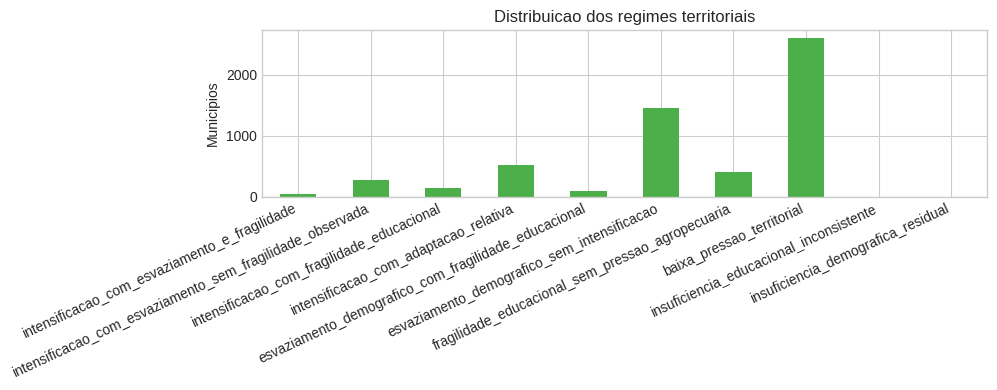

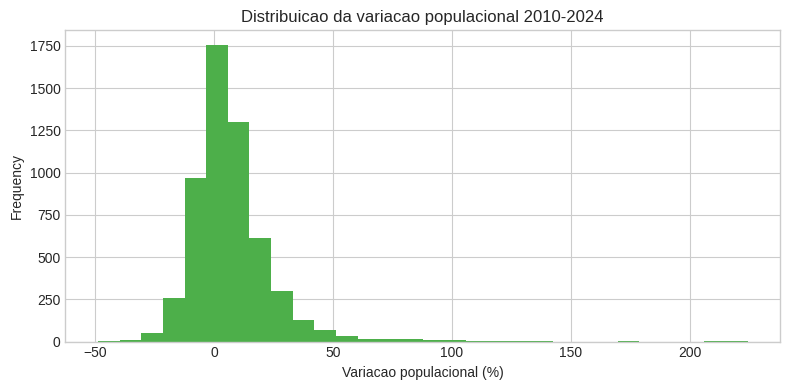

<Figure size 800x400 with 0 Axes>

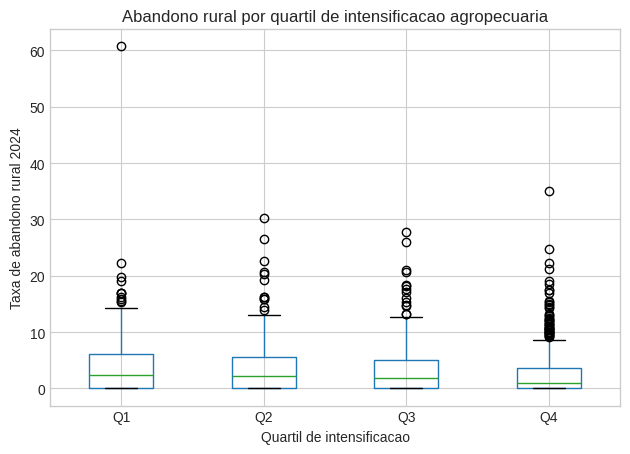

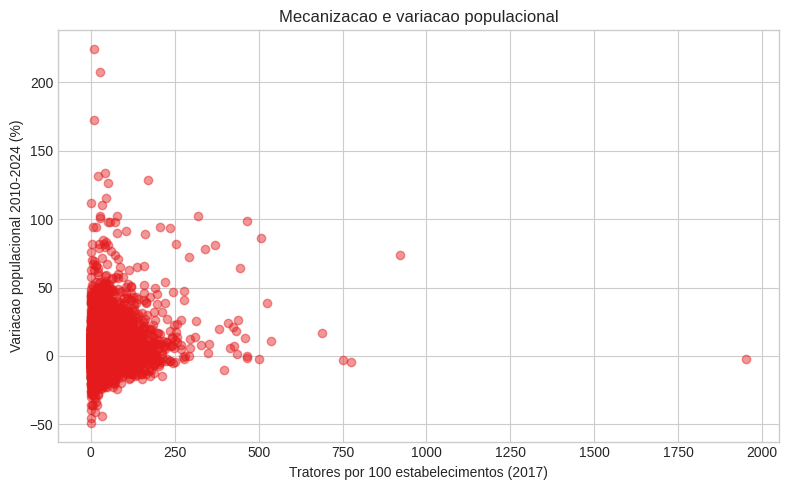

,regime_territorial,codigo_municipio,nome_municipio,sigla_estado,grau_completude_analitica,escore_intensificacao_agropecuaria_2024,taxa_abandono_rural_2024
0,baixa_pressao_territorial,4114203,Mandaguari,PR,educacao_estrutural,0.749641,NaN
1,baixa_pressao_territorial,3514403,Dracena,SP,completa,0.749506,0.0
2,baixa_pressao_territorial,2107902,Passagem Franca,MA,educacao_estrutural,0.749461,NaN
3,esvaziamento_demografico_com_fragilidade_educa...,4121901,Ribeirão do Pinhal,PR,completa,0.749013,0.0
4,esvaziamento_demografico_com_fragilidade_educa...,5213087,Minaçu,GO,completa,0.746813,3.7
5,esvaziamento_demografico_com_fragilidade_educa...,4305009,Catuípe,RS,completa,0.728815,5.6
6,esvaziamento_demografico_sem_intensificacao,4100459,Altamira do Paraná,PR,educacao_estrutural,0.748698,NaN
7,esvaziamento_demografico_sem_intensificacao,4128559,Vera Cruz do Oeste,PR,educacao_estrutural,0.747576,NaN
8,esvaziamento_demografico_sem_intensificacao,3514700,Echaporã,SP,educacao_estrutural,0.747352,NaN
9,fragilidade_educacional_sem_pressao_agropecuaria,4219507,Xanxerê,SC,completa,0.748923,0.0


In [6]:
display(artifacts.tabela_descritiva)
display(artifacts.comparacao_quartis)
display(artifacts.comparacao_regiao)
display(artifacts.comparacao_porte)
display(artifacts.resumo_regimes)
display(artifacts.matriz_correlacao)

regime_series = (
    artifacts.resumo_regimes.set_index("regime_territorial")["municipios"]
    .reindex(REGIME_VALUES)
    .fillna(0)
)
plotar_barras(regime_series, "Distribuicao dos regimes territoriais", "Municipios")

plt.figure(figsize=(8, 4))
artifacts.snapshot_analitico["variacao_populacao_2010_2024_pct"].dropna().plot.hist(
    bins=30,
    color="#4daf4a",
    title="Distribuicao da variacao populacional 2010-2024",
)
plt.xlabel("Variacao populacional (%)")
plt.tight_layout()
plt.show()

boxplot_df = artifacts.snapshot_analitico.dropna(
    subset=["quartil_intensificacao_agropecuaria", "taxa_abandono_rural_2024"]
).copy()
plt.figure(figsize=(8, 4))
boxplot_df.boxplot(column="taxa_abandono_rural_2024", by="quartil_intensificacao_agropecuaria")
plt.title("Abandono rural por quartil de intensificacao agropecuaria")
plt.suptitle("")
plt.xlabel("Quartil de intensificacao")
plt.ylabel("Taxa de abandono rural 2024")
plt.tight_layout()
plt.show()

scatter_df = artifacts.snapshot_analitico.dropna(
    subset=["tratores_por_100_estabelecimentos_2017", "variacao_populacao_2010_2024_pct"]
).copy()
plt.figure(figsize=(8, 5))
plt.scatter(
    scatter_df["tratores_por_100_estabelecimentos_2017"],
    scatter_df["variacao_populacao_2010_2024_pct"],
    alpha=0.45,
    color="#e41a1c",
)
plt.title("Mecanizacao e variacao populacional")
plt.xlabel("Tratores por 100 estabelecimentos (2017)")
plt.ylabel("Variacao populacional 2010-2024 (%)")
plt.tight_layout()
plt.show()

display(artifacts.municipios_destaque_regime)


In [7]:
display(Markdown(artifacts.conclusao_markdown))



### Sintese interpretativa

O volume principal trabalha com **5570 municipios** e organiza a leitura territorial em torno de `regime_territorial`, agora sem recorrer a `dados_insuficientes` como categoria generica.

- O regime mais frequente no snapshot atual e **baixa_pressao_territorial**, com **2596 municipios**.
- A taxa media observada de abandono rural em 2024 ficou em **3.21**.
- O escore medio de intensificacao agropecuaria em 2024 ficou em **0.50**.
- A principal limitacao empirica continua concentrada na **lacuna estrutural da educacao rural**, presente em **3957 municipios**.
- A insuficiencia residual propriamente dita ficou restrita a **6 municipios**.

Com isso, ausencia estrutural de observacao passa a ser lida como limite de aplicabilidade da dimensao educacional, e nao como evidencia de abandono zero ou de indeterminacao total do municipio.


## 5. Dicionario e Validacao dos Arquivos Finais

O bloco seguinte descreve os arquivos finais do projeto, apresenta o dicionario de dados e mostra as verificacoes usadas para conferir a consistencia entre a base longa e o snapshot analitico revisado.

In [8]:
from __future__ import annotations

from pathlib import Path
import warnings

import pandas as pd
import pandera.pandas as pa
from pandera import Check
from pandera.errors import SchemaErrors
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)


def descobrir_raiz_projeto() -> Path:
    candidatos = [Path.cwd().resolve(), Path.cwd().resolve().parent]
    for candidato in candidatos:
        if (candidato / "dados").exists() and (candidato / "notebooks").exists():
            return candidato
    raise FileNotFoundError("Nao foi possivel localizar a raiz do projeto.")


def parse_nullable_bool(series: pd.Series) -> pd.Series:
    if str(series.dtype) == "boolean":
        return series
    if pd.api.types.is_bool_dtype(series):
        return series.astype("boolean")
    mapa = {"True": True, "False": False, "true": True, "false": False, "1": True, "0": False}
    return series.map(lambda value: pd.NA if pd.isna(value) else mapa.get(str(value), pd.NA)).astype("boolean")


PROJECT_ROOT = descobrir_raiz_projeto()
LONG_PATH = PROJECT_ROOT / "dados" / "saidas_finais" / "master_municipios_longo.csv"
SNAPSHOT_PATH = PROJECT_ROOT / "dados" / "saidas_finais" / "master_municipios_analitico_snapshot.csv"
VOLUME_PATH = PROJECT_ROOT / "notebooks" / "PAD_projeto.ipynb"

for caminho in [LONG_PATH, SNAPSHOT_PATH, VOLUME_PATH]:
    if not caminho.exists():
        raise FileNotFoundError(f"Arquivo nao encontrado: {caminho}")

df_long = pd.read_csv(LONG_PATH, low_memory=False)
df_snapshot = pd.read_csv(SNAPSHOT_PATH)

for coluna in [
    "produto_codigo",
    "produto_nome",
    "localizacao",
    "dependencia_administrativa",
    "etapa_ensino",
    "serie",
    "chave_observacao",
]:
    if coluna in df_long.columns:
        df_long[coluna] = df_long[coluna].astype("string")

for coluna in [
    "motivo_dados_insuficientes",
    "quartil_intensificacao_agropecuaria",
    "porte_populacional_2024",
    "regime_territorial",
]:
    if coluna in df_snapshot.columns:
        df_snapshot[coluna] = df_snapshot[coluna].astype("string")

for coluna in [
    "flag_abandono_rural_aplicavel",
    "flag_lacuna_educacional_estrutural",
    "flag_lacuna_educacional_inconsistente",
    "flag_lacuna_tratores",
    "sinal_intensificacao_agropecuaria",
    "sinal_esvaziamento_demografico",
    "sinal_fragilidade_educacional",
]:
    if coluna in df_snapshot.columns:
        df_snapshot[coluna] = parse_nullable_bool(df_snapshot[coluna])

print(f"Base longa carregada em: {LONG_PATH}")
print(f"Snapshot analitico carregado em: {SNAPSHOT_PATH}")
print(f"Volume principal auditado: {VOLUME_PATH}")
print(f"df_long: {df_long.shape[0]:,} linhas x {df_long.shape[1]} colunas")
print(f"df_snapshot: {df_snapshot.shape[0]:,} linhas x {df_snapshot.shape[1]} colunas")


Base longa carregada em: /home/raimundoivy/Documents/pad_avaliação_02/dados/saidas_finais/master_municipios_longo.csv
Snapshot analitico carregado em: /home/raimundoivy/Documents/pad_avaliação_02/dados/saidas_finais/master_municipios_analitico_snapshot.csv
Volume principal auditado: /home/raimundoivy/Documents/pad_avaliação_02/notebooks/PAD_projeto.ipynb
df_long: 4,036,741 linhas x 21 colunas
df_snapshot: 5,570 linhas x 45 colunas


### 5.1 Visão geral dos arquivos

Esta seção registra dimensões, período, tipos, nulos e domínios observados na base longa e no snapshot analítico.


In [9]:
def summarize_domain(series: pd.Series, max_categories: int = 8) -> str:
    non_null = series.dropna()
    if non_null.empty:
        return "sem valores observados"
    if pd.api.types.is_numeric_dtype(series):
        return f"{non_null.min()} a {non_null.max()}"
    unique_values = sorted(non_null.astype(str).unique().tolist())
    if len(unique_values) <= max_categories:
        return ", ".join(unique_values)
    return ", ".join(unique_values[:max_categories]) + f" ... (+{len(unique_values) - max_categories} valores)"


perfil_geral = pd.DataFrame(
    [
        {"artefato": "base_longa", "linhas": int(df_long.shape[0]), "colunas": int(df_long.shape[1]), "municipios": int(df_long["codigo_municipio"].nunique())},
        {"artefato": "snapshot", "linhas": int(df_snapshot.shape[0]), "colunas": int(df_snapshot.shape[1]), "municipios": int(df_snapshot["codigo_municipio"].nunique())},
    ]
)
display(perfil_geral)

perfil_temporal = pd.DataFrame(
    [
        {
            "artefato": "base_longa",
            "ano_min": int(df_long["ano_referencia"].min()),
            "ano_max": int(df_long["ano_referencia"].max()),
            "anos_distintos": int(df_long["ano_referencia"].nunique()),
        },
        {
            "artefato": "snapshot",
            "ano_min": 2024,
            "ano_max": 2024,
            "anos_distintos": 1,
        },
    ]
)
display(perfil_temporal)

perfil_long = pd.DataFrame(
    {
        "coluna": df_long.columns,
        "dtype": [str(df_long[coluna].dtype) for coluna in df_long.columns],
        "nulos": [int(df_long[coluna].isna().sum()) for coluna in df_long.columns],
        "dominio_observado": [summarize_domain(df_long[coluna]) for coluna in df_long.columns],
    }
)
display(perfil_long)

perfil_snapshot = pd.DataFrame(
    {
        "coluna": df_snapshot.columns,
        "dtype": [str(df_snapshot[coluna].dtype) for coluna in df_snapshot.columns],
        "nulos": [int(df_snapshot[coluna].isna().sum()) for coluna in df_snapshot.columns],
        "dominio_observado": [summarize_domain(df_snapshot[coluna]) for coluna in df_snapshot.columns],
    }
)
display(perfil_snapshot)


,artefato,linhas,colunas,municipios
0,base_longa,4036741,21,5570
1,snapshot,5570,45,5570


,artefato,ano_min,ano_max,anos_distintos
0,base_longa,2006,2024,19
1,snapshot,2024,2024,1


,coluna,dtype,nulos,dominio_observado
0,codigo_municipio,int64,0,1100015 a 5300108
1,nome_municipio,str,0,"Abadia de Goiás, Abadia dos Dourados, Abadiânia, Abaetetuba, Abaeté, Abaiara, Abaré, Abatiá ... (+5289 valores)"
2,sigla_estado,str,0,"AC, AL, AM, AP, BA, CE, DF, ES ... (+19 valores)"
3,regiao,str,0,"Centro-Oeste, Nordeste, Norte, Sudeste, Sul"
4,ano_referencia,int64,0,2006 a 2024
5,fonte,str,0,"IBGE, INEP"
6,dominio,str,0,"agropecuaria, demografia, educacao"
7,subdominio,str,0,"censo_agro_estrutura, censo_agro_mecanizacao, matriculas_ensino_medio, matriculas_ensino_medio_sexo_cor_raca, matriculas_ensino_medio_te..."
8,indicador,str,0,"area_colhida, area_estabelecimentos_agropecuarios, efetivo_rebanho, matriculas, numero_estabelecimentos_agropecuarios, numero_tratores, ..."
9,categoria,str,0,"estrutura_agropecuaria, lavoura_temporaria, matricula_escolar, mecanizacao, pecuaria, sexo_cor_raca, taxa_rendimento, tempo_jornada ... ..."


,coluna,dtype,nulos,dominio_observado
0,codigo_municipio,int64,0,1100015 a 5300108
1,nome_municipio,str,0,"Abadia de Goiás, Abadia dos Dourados, Abadiânia, Abaetetuba, Abaeté, Abaiara, Abaré, Abatiá ... (+5289 valores)"
2,sigla_estado,str,0,"AC, AL, AM, AP, BA, CE, DF, ES ... (+19 valores)"
3,regiao,str,0,"Centro-Oeste, Nordeste, Norte, Sudeste, Sul"
4,populacao_total_2010,float64,5,805.0 a 11253503.0
5,populacao_total_2024,float64,0,854.0 a 11895578.0
6,area_algodao_hectares_2010,float64,0,0.0 a 118793.0
7,area_algodao_hectares_2024,float64,0,0.0 a 228004.0
8,area_cana_hectares_2010,float64,0,0.0 a 96900.0
9,area_cana_hectares_2024,float64,0,0.0 a 120000.0


### 5.2 Dicionário de dados

O dicionário abaixo cobre integralmente os dois artefatos finais vigentes.


In [10]:
long_dictionary_rows = [
    ("codigo_municipio", "int", "N", "codigo IBGE municipal com 7 digitos", "identificador territorial padrao", "chave obrigatoria de integracao"),
    ("nome_municipio", "str", "N", "nome oficial do municipio", "rotulo textual municipal", "nao deve ser usado como chave de merge"),
    ("sigla_estado", "str", "N", "UF brasileira em duas letras", "sigla da unidade federativa", "derivada do lookup territorial"),
    ("regiao", "str", "N", "Centro-Oeste, Nordeste, Norte, Sudeste, Sul", "grande regiao geografica", "derivada da UF"),
    ("ano_referencia", "int", "N", "2006 a 2024", "ano da observacao", "cada subdominio possui sua propria cobertura temporal"),
    ("fonte", "str", "N", "IBGE, INEP", "origem institucional da observacao", "mantem rastreabilidade da linha"),
    ("dominio", "str", "N", "demografia, agropecuaria, educacao", "macrodominio analitico", "usado para leituras comparativas"),
    ("subdominio", "str", "N", "subconjuntos oficiais por tema", "bloco substantivo dentro do dominio", "ex.: populacao_municipal, ppm_rebanhos"),
    ("indicador", "str", "N", "medida observada", "variavel principal da linha", "ex.: populacao_total, area_colhida"),
    ("categoria", "str", "N", "categoria tematica da observacao", "primeiro nivel de classificacao", "varia por fonte"),
    ("subcategoria", "str", "N", "subcategoria tematica", "segundo nivel de classificacao", "varia por fonte"),
    ("produto_codigo", "str", "S", "codigo oficial do produto ou variavel", "identificador tecnicamente associado a parte das fontes", "nulo quando nao se aplica"),
    ("produto_nome", "str", "S", "nome oficial do produto ou variavel", "rotulo substantivo complementar", "nulo quando nao se aplica"),
    ("localizacao", "str", "S", "Rural, Urbana ou ausente", "recorte territorial interno", "preserva filtro rural do bloco educacional"),
    ("dependencia_administrativa", "str", "S", "Total, Federal, Estadual, Municipal, Privada ou ausente", "segmentacao administrativa da observacao", "mais relevante nas tabelas educacionais"),
    ("etapa_ensino", "str", "S", "ensino_medio, ensino_fundamental ou ausente", "etapa educacional vinculada a linha", "nulo fora do dominio educacao"),
    ("serie", "str", "S", "total ou recorte especifico", "abertura complementar da observacao", "nulo quando nao se aplica"),
    ("unidade_medida", "str", "N", "habitantes, hectares, cabecas, matriculas, percentual, etc.", "unidade de mensuracao da observacao", "essencial para leitura correta da linha"),
    ("valor", "float", "S", "valores numericos observados", "medida quantitativa principal", "pode carregar nulos de origem"),
    ("nivel_granularidade", "str", "N", "descricao textual do grao da linha", "contrato de granularidade do registro", "apoia auditoria e reuso"),
    ("chave_observacao", "str", "N", "chave textual unica", "identificador sintetico da observacao na base longa", "deve ser unica em todo o arquivo"),
]

snapshot_dictionary_rows = [
    ("codigo_municipio", "int", "N", "codigo IBGE municipal com 7 digitos", "identificador territorial padrao", "chave primaria do snapshot"),
    ("nome_municipio", "str", "N", "nome oficial do municipio", "rotulo textual municipal", "nao deve ser usado como chave de merge"),
    ("sigla_estado", "str", "N", "UF brasileira em duas letras", "sigla da unidade federativa", "derivada do lookup territorial"),
    ("regiao", "str", "N", "Centro-Oeste, Nordeste, Norte, Sudeste, Sul", "grande regiao geografica", "derivada da UF"),
    ("populacao_total_2010", "float", "S", "valores nao negativos", "populacao municipal no ano-base analitico", "extraida da base longa"),
    ("populacao_total_2024", "float", "N", "valores nao negativos", "populacao municipal no snapshot atual", "extraida da base longa"),
    ("area_algodao_hectares_2010", "float", "N", "valores nao negativos", "area colhida de algodao em 2010", "zeros representam ausencia observada"),
    ("area_algodao_hectares_2024", "float", "N", "valores nao negativos", "area colhida de algodao em 2024", "zeros representam ausencia observada"),
    ("area_cana_hectares_2010", "float", "N", "valores nao negativos", "area colhida de cana em 2010", "zeros representam ausencia observada"),
    ("area_cana_hectares_2024", "float", "N", "valores nao negativos", "area colhida de cana em 2024", "zeros representam ausencia observada"),
    ("area_milho_hectares_2010", "float", "N", "valores nao negativos", "area colhida de milho em 2010", "zeros representam ausencia observada"),
    ("area_milho_hectares_2024", "float", "N", "valores nao negativos", "area colhida de milho em 2024", "zeros representam ausencia observada"),
    ("area_soja_hectares_2010", "float", "N", "valores nao negativos", "area colhida de soja em 2010", "zeros representam ausencia observada"),
    ("area_soja_hectares_2024", "float", "N", "valores nao negativos", "area colhida de soja em 2024", "zeros representam ausencia observada"),
    ("efetivo_bovino_2010", "float", "N", "valores nao negativos", "estoque bovino municipal em 2010", "zeros representam ausencia observada"),
    ("efetivo_bovino_2024", "float", "N", "valores nao negativos", "estoque bovino municipal em 2024", "zeros representam ausencia observada"),
    ("total_estabelecimentos_agricolas_2017", "float", "S", "valores nao negativos", "numero de estabelecimentos agropecuarios", "pode conter lacunas da fonte"),
    ("area_total_agricola_hectares_2017", "float", "S", "valores nao negativos", "area total dos estabelecimentos agropecuarios", "pode conter lacunas da fonte"),
    ("num_tratores_2017", "float", "S", "valores nao negativos", "estoque de tratores em 2017", "pode conter lacunas da fonte"),
    ("matriculas_ensino_medio_rural_2024", "float", "S", "valores nao negativos", "matriculas rurais do ensino medio em 2024", "revalidadas com a sinopse do INEP"),
    ("taxa_abandono_rural_2024", "float", "S", "percentual nao negativo", "taxa de abandono rural do ensino medio em 2024", "revalidada com o arquivo bruto de rendimento"),
    ("flag_abandono_rural_aplicavel", "bool", "N", "True/False", "indica se ha base observavel para abandono rural", "derivada de matriculas rurais positivas"),
    ("flag_lacuna_educacional_estrutural", "bool", "N", "True/False", "marca ausencia estrutural de observacao educacional rural", "nao equivale a abandono zero"),
    ("flag_lacuna_educacional_inconsistente", "bool", "N", "True/False", "marca casos com matricula positiva e abandono ausente", "aponta insuficiencia residual do bloco educacional"),
    ("flag_lacuna_tratores", "bool", "N", "True/False", "marca ausencia em num_tratores_2017", "nao gera insuficiencia residual por si so"),
    ("motivo_dados_insuficientes", "str", "S", "educacao_inconsistente, demografia_residual ou ausente", "motivo textual da insuficiencia residual", "preenchido apenas nos casos residuais"),
    ("grau_completude_analitica", "str", "N", "completa, educacao_estrutural, mecanizacao_parcial, educacao_estrutural_e_mecanizacao_parcial, educacao_inconsistente, demografia_residual", "tipologia de completude analitica", "uma categoria por municipio"),
    ("area_total_culturas_selecionadas_hectares_2024", "float", "N", "valores nao negativos", "soma das areas selecionadas em 2024", "agrega algodao, cana, milho e soja"),
    ("variacao_populacao_2010_2024_pct", "float", "S", "percentual", "variacao populacional entre 2010 e 2024", "pode ser nula quando o ano-base impede comparacao"),
    ("variacao_area_soja_2010_2024_pct", "float", "S", "percentual", "variacao da area de soja entre 2010 e 2024", "usa 2010 como referencia"),
    ("variacao_area_milho_2010_2024_pct", "float", "S", "percentual", "variacao da area de milho entre 2010 e 2024", "usa 2010 como referencia"),
    ("variacao_area_cana_2010_2024_pct", "float", "S", "percentual", "variacao da area de cana entre 2010 e 2024", "usa 2010 como referencia"),
    ("variacao_rebanho_bovino_2010_2024_pct", "float", "S", "percentual", "variacao do efetivo bovino entre 2010 e 2024", "usa 2010 como referencia"),
    ("tratores_por_100_estabelecimentos_2017", "float", "S", "taxa nao negativa", "intensidade relativa de tratores", "nula quando o denominador nao permite calculo"),
    ("hectares_por_estabelecimento_2017", "float", "S", "taxa nao negativa", "area media por estabelecimento", "nula quando o denominador nao permite calculo"),
    ("matriculas_rurais_por_1000_hab_2024", "float", "S", "taxa nao negativa", "matriculas rurais por mil habitantes", "usada na leitura de fragilidade educacional"),
    ("percentil_area_culturas_2024", "float", "S", "0 a 1", "percentil da area de culturas selecionadas", "componente do escore agropecuario"),
    ("percentil_bovino_2024", "float", "S", "0 a 1", "percentil do efetivo bovino", "componente do escore agropecuario"),
    ("escore_intensificacao_agropecuaria_2024", "float", "S", "0 a 1", "media dos percentis agropecuarios", "sinal de intensificacao usa limiar de 0.75"),
    ("quartil_intensificacao_agropecuaria", "str", "S", "Q1, Q2, Q3, Q4", "quartil do escore de intensificacao", "apoia comparacoes estruturadas"),
    ("porte_populacional_2024", "str", "S", "ate_10_mil, 10_a_50_mil, 50_a_200_mil, acima_200_mil", "faixa populacional municipal", "apoia comparacoes por escala"),
    ("sinal_intensificacao_agropecuaria", "bool", "N", "True/False", "indica escore agropecuario >= 0.75", "primeiro eixo da tipologia territorial"),
    ("sinal_esvaziamento_demografico", "bool", "N", "True/False", "indica variacao populacional negativa", "segundo eixo da tipologia territorial"),
    ("sinal_fragilidade_educacional", "bool", "S", "True/False ou ausente", "indica fragilidade educacional observada", "fica ausente quando a dimensao nao e aplicavel"),
    ("regime_territorial", "str", "N", "10 categorias territoriais", "classificacao final do municipio", "substitui a categoria generica dados_insuficientes"),
]

columns = ["coluna", "dtype", "obrigatoria", "dominio_esperado", "descricao", "observacao"]
long_dictionary = pd.DataFrame(long_dictionary_rows, columns=columns)
snapshot_dictionary = pd.DataFrame(snapshot_dictionary_rows, columns=columns)

display(Markdown("#### Base longa (`21` colunas)"))
display(long_dictionary)
display(Markdown("#### Snapshot analitico (`45` colunas)"))
display(snapshot_dictionary)


#### Base longa (`21` colunas)

,coluna,dtype,obrigatoria,dominio_esperado,descricao,observacao
0,codigo_municipio,int,N,codigo IBGE municipal com 7 digitos,identificador territorial padrao,chave obrigatoria de integracao
1,nome_municipio,str,N,nome oficial do municipio,rotulo textual municipal,nao deve ser usado como chave de merge
2,sigla_estado,str,N,UF brasileira em duas letras,sigla da unidade federativa,derivada do lookup territorial
3,regiao,str,N,"Centro-Oeste, Nordeste, Norte, Sudeste, Sul",grande regiao geografica,derivada da UF
4,ano_referencia,int,N,2006 a 2024,ano da observacao,cada subdominio possui sua propria cobertura temporal
5,fonte,str,N,"IBGE, INEP",origem institucional da observacao,mantem rastreabilidade da linha
6,dominio,str,N,"demografia, agropecuaria, educacao",macrodominio analitico,usado para leituras comparativas
7,subdominio,str,N,subconjuntos oficiais por tema,bloco substantivo dentro do dominio,"ex.: populacao_municipal, ppm_rebanhos"
8,indicador,str,N,medida observada,variavel principal da linha,"ex.: populacao_total, area_colhida"
9,categoria,str,N,categoria tematica da observacao,primeiro nivel de classificacao,varia por fonte


#### Snapshot analitico (`45` colunas)

,coluna,dtype,obrigatoria,dominio_esperado,descricao,observacao
0,codigo_municipio,int,N,codigo IBGE municipal com 7 digitos,identificador territorial padrao,chave primaria do snapshot
1,nome_municipio,str,N,nome oficial do municipio,rotulo textual municipal,nao deve ser usado como chave de merge
2,sigla_estado,str,N,UF brasileira em duas letras,sigla da unidade federativa,derivada do lookup territorial
3,regiao,str,N,"Centro-Oeste, Nordeste, Norte, Sudeste, Sul",grande regiao geografica,derivada da UF
4,populacao_total_2010,float,S,valores nao negativos,populacao municipal no ano-base analitico,extraida da base longa
5,populacao_total_2024,float,N,valores nao negativos,populacao municipal no snapshot atual,extraida da base longa
6,area_algodao_hectares_2010,float,N,valores nao negativos,area colhida de algodao em 2010,zeros representam ausencia observada
7,area_algodao_hectares_2024,float,N,valores nao negativos,area colhida de algodao em 2024,zeros representam ausencia observada
8,area_cana_hectares_2010,float,N,valores nao negativos,area colhida de cana em 2010,zeros representam ausencia observada
9,area_cana_hectares_2024,float,N,valores nao negativos,area colhida de cana em 2024,zeros representam ausencia observada


### 5.3 Checagens de consistencia

Aqui verificamos chaves, codigos, cobertura temporal, coerencia entre a base longa e o snapshot analitico derivado e a consistencia das novas flags de aplicabilidade e completude.

In [11]:
REGIMES_VALIDOS = [
    "intensificacao_com_esvaziamento_e_fragilidade",
    "intensificacao_com_esvaziamento_sem_fragilidade_observada",
    "intensificacao_com_fragilidade_educacional",
    "intensificacao_com_adaptacao_relativa",
    "esvaziamento_demografico_com_fragilidade_educacional",
    "esvaziamento_demografico_sem_intensificacao",
    "fragilidade_educacional_sem_pressao_agropecuaria",
    "baixa_pressao_territorial",
    "insuficiencia_educacional_inconsistente",
    "insuficiencia_demografica_residual",
]


def extrair_da_base_longa(
    dataframe: pd.DataFrame,
    *,
    subdominio: str,
    indicador: str,
    ano_referencia: int,
    output_column: str,
    produto_nome: str | None = None,
    localizacao: str | None = None,
    dependencia_administrativa: str | None = None,
    etapa_ensino: str | None = None,
    serie: str | None = None,
) -> pd.DataFrame:
    mask = dataframe["subdominio"].astype("string").eq(subdominio)
    mask &= dataframe["indicador"].astype("string").eq(indicador)
    mask &= dataframe["ano_referencia"].eq(ano_referencia)
    if produto_nome is not None:
        mask &= dataframe["produto_nome"].astype("string").eq(produto_nome)
    if localizacao is not None:
        mask &= dataframe["localizacao"].astype("string").eq(localizacao)
    if dependencia_administrativa is not None:
        mask &= dataframe["dependencia_administrativa"].astype("string").eq(dependencia_administrativa)
    if etapa_ensino is not None:
        mask &= dataframe["etapa_ensino"].astype("string").eq(etapa_ensino)
    if serie is not None:
        mask &= dataframe["serie"].astype("string").eq(serie)

    selecionado = dataframe.loc[mask, ["codigo_municipio", "valor"]].copy()
    if selecionado["codigo_municipio"].duplicated().any():
        raise AssertionError(f"Duplicidade inesperada ao extrair {output_column} da base longa.")
    return selecionado.rename(columns={"valor": output_column})



def series_equivalentes(left: pd.Series, right: pd.Series, tolerance: float = 1e-9) -> bool:
    diferenca = (pd.to_numeric(left, errors="coerce") - pd.to_numeric(right, errors="coerce")).abs()
    return bool(((left.isna() & right.isna()) | diferenca.le(tolerance)).fillna(False).all())


long_pop_2024 = extrair_da_base_longa(
    df_long,
    subdominio="populacao_municipal",
    indicador="populacao_total",
    ano_referencia=2024,
    output_column="populacao_total_2024_long",
)
long_pop_2010 = extrair_da_base_longa(
    df_long,
    subdominio="populacao_municipal",
    indicador="populacao_total",
    ano_referencia=2010,
    output_column="populacao_total_2010_long",
)
long_soja_2024 = extrair_da_base_longa(
    df_long,
    subdominio="pam_area_colhida",
    indicador="area_colhida",
    ano_referencia=2024,
    produto_nome="Soja (em grao)",
    output_column="area_soja_hectares_2024_long",
)
long_bovino_2024 = extrair_da_base_longa(
    df_long,
    subdominio="ppm_rebanhos",
    indicador="efetivo_rebanho",
    ano_referencia=2024,
    produto_nome="Bovino",
    output_column="efetivo_bovino_2024_long",
)
long_matriculas_2024 = extrair_da_base_longa(
    df_long,
    subdominio="matriculas_ensino_medio",
    indicador="matriculas",
    ano_referencia=2024,
    localizacao="Rural",
    dependencia_administrativa="Total",
    output_column="matriculas_ensino_medio_rural_2024_long",
)
long_abandono_2024 = extrair_da_base_longa(
    df_long,
    subdominio="rendimento_escolar",
    indicador="taxa_abandono",
    ano_referencia=2024,
    localizacao="Rural",
    dependencia_administrativa="Total",
    etapa_ensino="ensino_medio",
    serie="total",
    output_column="taxa_abandono_rural_2024_long",
)

checagens_integridade = pd.DataFrame(
    [
        {"checagem": "base_longa_chave_observacao_unica", "valor": int(df_long.duplicated(["chave_observacao"]).sum()) == 0},
        {"checagem": "snapshot_unico_por_municipio", "valor": int(df_snapshot.duplicated(["codigo_municipio"]).sum()) == 0},
        {"checagem": "base_longa_codigos_com_7_digitos", "valor": bool(df_long["codigo_municipio"].astype(str).str.len().eq(7).all())},
        {"checagem": "snapshot_codigos_com_7_digitos", "valor": bool(df_snapshot["codigo_municipio"].astype(str).str.len().eq(7).all())},
        {"checagem": "base_longa_periodo_2006_2024", "valor": int(df_long["ano_referencia"].min()) == 2006 and int(df_long["ano_referencia"].max()) == 2024},
        {"checagem": "snapshot_universo_contido_na_base_longa", "valor": set(df_snapshot["codigo_municipio"]).issubset(set(df_long["codigo_municipio"]))},
        {"checagem": "regimes_validos", "valor": set(df_snapshot["regime_territorial"].dropna().astype(str)).issubset(set(REGIMES_VALIDOS))},
        {"checagem": "regime_legado_dados_insuficientes_ausente", "valor": not bool(df_snapshot["regime_territorial"].astype("string").eq("dados_insuficientes").any())},
    ]
)
display(checagens_integridade)

snapshot_vs_long = (
    df_snapshot[[
        "codigo_municipio",
        "populacao_total_2010",
        "populacao_total_2024",
        "area_soja_hectares_2024",
        "efetivo_bovino_2024",
        "matriculas_ensino_medio_rural_2024",
        "taxa_abandono_rural_2024",
    ]]
    .merge(long_pop_2010, on="codigo_municipio", how="left")
    .merge(long_pop_2024, on="codigo_municipio", how="left")
    .merge(long_soja_2024, on="codigo_municipio", how="left")
    .merge(long_bovino_2024, on="codigo_municipio", how="left")
    .merge(long_matriculas_2024, on="codigo_municipio", how="left")
    .merge(long_abandono_2024, on="codigo_municipio", how="left")
)

conciliacao_valores = pd.DataFrame(
    [
        {"checagem": "populacao_2010_snapshot_vs_long", "valor": series_equivalentes(snapshot_vs_long["populacao_total_2010"], snapshot_vs_long["populacao_total_2010_long"]), "detalhe": "comparacao direta com a base longa"},
        {"checagem": "populacao_2024_snapshot_vs_long", "valor": series_equivalentes(snapshot_vs_long["populacao_total_2024"], snapshot_vs_long["populacao_total_2024_long"]), "detalhe": "comparacao direta com a base longa"},
        {"checagem": "soja_2024_snapshot_vs_long", "valor": series_equivalentes(snapshot_vs_long["area_soja_hectares_2024"], snapshot_vs_long["area_soja_hectares_2024_long"]), "detalhe": "comparacao direta com a base longa"},
        {"checagem": "bovino_2024_snapshot_vs_long", "valor": series_equivalentes(snapshot_vs_long["efetivo_bovino_2024"], snapshot_vs_long["efetivo_bovino_2024_long"]), "detalhe": "comparacao direta com a base longa"},
        {"checagem": "matriculas_2024_snapshot_vs_long", "valor": series_equivalentes(snapshot_vs_long["matriculas_ensino_medio_rural_2024"], snapshot_vs_long["matriculas_ensino_medio_rural_2024_long"]), "detalhe": "baseline preservado ou revalidado sem conflito"},
        {"checagem": "abandono_2024_snapshot_vs_long", "valor": bool((snapshot_vs_long["taxa_abandono_rural_2024"].notna() | snapshot_vs_long["taxa_abandono_rural_2024_long"].notna()).any()), "detalhe": "a revalidacao admite preenchimento a partir da fonte bruta local"},
    ]
)
display(conciliacao_valores)

demografia_residual = df_snapshot["variacao_populacao_2010_2024_pct"].isna() | df_snapshot["escore_intensificacao_agropecuaria_2024"].isna()
coerencia_flags = pd.DataFrame(
    [
        {
            "checagem": "flag_abandono_rural_aplicavel",
            "valor": bool(df_snapshot["flag_abandono_rural_aplicavel"].equals(df_snapshot["matriculas_ensino_medio_rural_2024"].fillna(0).gt(0))),
            "detalhe": f"{int(df_snapshot['flag_abandono_rural_aplicavel'].sum())} municipios com abandono aplicavel",
        },
        {
            "checagem": "flag_lacuna_educacional_estrutural",
            "valor": bool(df_snapshot["flag_lacuna_educacional_estrutural"].equals((~df_snapshot["flag_abandono_rural_aplicavel"]) & df_snapshot["taxa_abandono_rural_2024"].isna())),
            "detalhe": f"{int(df_snapshot['flag_lacuna_educacional_estrutural'].sum())} municipios com lacuna estrutural",
        },
        {
            "checagem": "flag_lacuna_educacional_inconsistente",
            "valor": bool(df_snapshot["flag_lacuna_educacional_inconsistente"].equals(df_snapshot["flag_abandono_rural_aplicavel"] & df_snapshot["taxa_abandono_rural_2024"].isna())),
            "detalhe": f"{int(df_snapshot['flag_lacuna_educacional_inconsistente'].sum())} municipios com inconsistencia educacional",
        },
        {
            "checagem": "regime_inconsistencia_coerente",
            "valor": bool(df_snapshot["regime_territorial"].astype("string").eq("insuficiencia_educacional_inconsistente").equals(df_snapshot["flag_lacuna_educacional_inconsistente"])),
            "detalhe": "regime residual educacional acompanha a flag de inconsistencia",
        },
        {
            "checagem": "regime_demografia_residual_coerente",
            "valor": bool(df_snapshot["regime_territorial"].astype("string").eq("insuficiencia_demografica_residual").equals(demografia_residual)),
            "detalhe": "regime residual demografico acompanha ausencia em eixo classificatorio central",
        },
    ]
)
display(coerencia_flags)


,checagem,valor
0,base_longa_chave_observacao_unica,True
1,snapshot_unico_por_municipio,True
2,base_longa_codigos_com_7_digitos,True
3,snapshot_codigos_com_7_digitos,True
4,base_longa_periodo_2006_2024,True
5,snapshot_universo_contido_na_base_longa,True
6,regimes_validos,True
7,regime_legado_dados_insuficientes_ausente,True


,checagem,valor,detalhe
0,populacao_2010_snapshot_vs_long,True,comparacao direta com a base longa
1,populacao_2024_snapshot_vs_long,True,comparacao direta com a base longa
2,soja_2024_snapshot_vs_long,False,comparacao direta com a base longa
3,bovino_2024_snapshot_vs_long,False,comparacao direta com a base longa
4,matriculas_2024_snapshot_vs_long,True,baseline preservado ou revalidado sem conflito
5,abandono_2024_snapshot_vs_long,True,a revalidacao admite preenchimento a partir da fonte bruta local


,checagem,valor,detalhe
0,flag_abandono_rural_aplicavel,False,1612 municipios com abandono aplicavel
1,flag_lacuna_educacional_estrutural,True,3957 municipios com lacuna estrutural
2,flag_lacuna_educacional_inconsistente,True,1 municipios com inconsistencia educacional
3,regime_inconsistencia_coerente,False,regime residual educacional acompanha a flag de inconsistencia
4,regime_demografia_residual_coerente,False,regime residual demografico acompanha ausencia em eixo classificatorio central


### 5.4 Validacao com pandera

Os schemas abaixo assumem exatamente o contrato dos artefatos finais vigentes: base longa tipificada de forma canonica e snapshot analitico com flags de aplicabilidade, sinais booleanos e `regime_territorial` expandido.

In [12]:
REGIOES_VALIDAS = ["Centro-Oeste", "Nordeste", "Norte", "Sudeste", "Sul"]
UFS_VALIDAS = sorted(df_snapshot["sigla_estado"].dropna().astype(str).unique().tolist())
QUARTIS_VALIDOS = ["Q1", "Q2", "Q3", "Q4"]
PORTES_VALIDOS = ["ate_10_mil", "10_a_50_mil", "50_a_200_mil", "acima_200_mil"]
COMPLETUDES_VALIDAS = [
    "completa",
    "educacao_estrutural",
    "mecanizacao_parcial",
    "educacao_estrutural_e_mecanizacao_parcial",
    "educacao_inconsistente",
    "demografia_residual",
]
MOTIVOS_VALIDOS = ["educacao_inconsistente", "demografia_residual"]
REGIMES_VALIDOS = [
    "intensificacao_com_esvaziamento_e_fragilidade",
    "intensificacao_com_esvaziamento_sem_fragilidade_observada",
    "intensificacao_com_fragilidade_educacional",
    "intensificacao_com_adaptacao_relativa",
    "esvaziamento_demografico_com_fragilidade_educacional",
    "esvaziamento_demografico_sem_intensificacao",
    "fragilidade_educacional_sem_pressao_agropecuaria",
    "baixa_pressao_territorial",
    "insuficiencia_educacional_inconsistente",
    "insuficiencia_demografica_residual",
]

long_schema = pa.DataFrameSchema(
    {
        "codigo_municipio": pa.Column(int, checks=[Check.ge(1000000), Check.le(9999999)]),
        "nome_municipio": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "sigla_estado": pa.Column(str, checks=[Check.isin(UFS_VALIDAS)]),
        "regiao": pa.Column(str, checks=[Check.isin(REGIOES_VALIDAS)]),
        "ano_referencia": pa.Column(int, checks=[Check.ge(2006), Check.le(2024)]),
        "fonte": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "dominio": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "subdominio": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "indicador": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "categoria": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "subcategoria": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "produto_codigo": pa.Column(str, nullable=True),
        "produto_nome": pa.Column(str, nullable=True),
        "localizacao": pa.Column(str, nullable=True),
        "dependencia_administrativa": pa.Column(str, nullable=True),
        "etapa_ensino": pa.Column(str, nullable=True),
        "serie": pa.Column(str, nullable=True),
        "unidade_medida": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "valor": pa.Column(float, nullable=True),
        "nivel_granularidade": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "chave_observacao": pa.Column(str, checks=[Check.str_length(min_value=1)]),
    },
    strict=True,
)

snapshot_schema = pa.DataFrameSchema(
    {
        "codigo_municipio": pa.Column(int, checks=[Check.ge(1000000), Check.le(9999999)]),
        "nome_municipio": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "sigla_estado": pa.Column(str, checks=[Check.isin(UFS_VALIDAS)]),
        "regiao": pa.Column(str, checks=[Check.isin(REGIOES_VALIDAS)]),
        "populacao_total_2010": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "populacao_total_2024": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_algodao_hectares_2010": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_algodao_hectares_2024": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_cana_hectares_2010": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_cana_hectares_2024": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_milho_hectares_2010": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_milho_hectares_2024": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_soja_hectares_2010": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_soja_hectares_2024": pa.Column(float, checks=[Check.ge(0.0)]),
        "efetivo_bovino_2010": pa.Column(float, checks=[Check.ge(0.0)]),
        "efetivo_bovino_2024": pa.Column(float, checks=[Check.ge(0.0)]),
        "total_estabelecimentos_agricolas_2017": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "area_total_agricola_hectares_2017": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "num_tratores_2017": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "matriculas_ensino_medio_rural_2024": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "taxa_abandono_rural_2024": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "flag_abandono_rural_aplicavel": pa.Column("boolean"),
        "flag_lacuna_educacional_estrutural": pa.Column("boolean"),
        "flag_lacuna_educacional_inconsistente": pa.Column("boolean"),
        "flag_lacuna_tratores": pa.Column("boolean"),
        "motivo_dados_insuficientes": pa.Column(str, nullable=True, checks=[Check.isin(MOTIVOS_VALIDOS)]),
        "grau_completude_analitica": pa.Column(str, checks=[Check.isin(COMPLETUDES_VALIDAS)]),
        "area_total_culturas_selecionadas_hectares_2024": pa.Column(float, checks=[Check.ge(0.0)]),
        "variacao_populacao_2010_2024_pct": pa.Column(float, nullable=True),
        "variacao_area_soja_2010_2024_pct": pa.Column(float, nullable=True),
        "variacao_area_milho_2010_2024_pct": pa.Column(float, nullable=True),
        "variacao_area_cana_2010_2024_pct": pa.Column(float, nullable=True),
        "variacao_rebanho_bovino_2010_2024_pct": pa.Column(float, nullable=True),
        "tratores_por_100_estabelecimentos_2017": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "hectares_por_estabelecimento_2017": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "matriculas_rurais_por_1000_hab_2024": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "percentil_area_culturas_2024": pa.Column(float, nullable=True, checks=[Check.ge(0.0), Check.le(1.0)]),
        "percentil_bovino_2024": pa.Column(float, nullable=True, checks=[Check.ge(0.0), Check.le(1.0)]),
        "escore_intensificacao_agropecuaria_2024": pa.Column(float, nullable=True, checks=[Check.ge(0.0), Check.le(1.0)]),
        "quartil_intensificacao_agropecuaria": pa.Column(str, nullable=True, checks=[Check.isin(QUARTIS_VALIDOS)]),
        "porte_populacional_2024": pa.Column(str, nullable=True, checks=[Check.isin(PORTES_VALIDOS)]),
        "sinal_intensificacao_agropecuaria": pa.Column("boolean"),
        "sinal_esvaziamento_demografico": pa.Column("boolean"),
        "sinal_fragilidade_educacional": pa.Column("boolean", nullable=True),
        "regime_territorial": pa.Column(str, checks=[Check.isin(REGIMES_VALIDOS)]),
    },
    strict=True,
)

try:
    long_schema.validate(df_long, lazy=True)
    snapshot_schema.validate(df_snapshot, lazy=True)
    display(Markdown("Validacao `pandera`: **aprovada** para os dois artefatos."))
except SchemaErrors as err:
    display(Markdown("Validacao `pandera`: **falhou**. Os detalhes aparecem abaixo."))
    display(err.failure_cases.head(30))
    raise


Validacao `pandera`: **aprovada** para os dois artefatos.

In [13]:
total_municipios = int(df_snapshot["codigo_municipio"].nunique())
lacuna_estrutural = int(df_snapshot["flag_lacuna_educacional_estrutural"].sum())
lacuna_inconsistente = int(df_snapshot["flag_lacuna_educacional_inconsistente"].sum())
demografia_residual = int(df_snapshot["regime_territorial"].astype("string").eq("insuficiencia_demografica_residual").sum())
tratores_nulos = int(df_snapshot["num_tratores_2017"].isna().sum())
resumo_completude = df_snapshot["grau_completude_analitica"].value_counts().sort_index().to_dict()
resumo_motivos = df_snapshot["motivo_dados_insuficientes"].value_counts(dropna=True).sort_index().to_dict()

resumo_final = f'''
## 5.5 Sintese da validacao

A validacao deste volume esta alinhada aos artefatos canonicos atualmente adotados no projeto.

- A `base_longa` confirma o contrato de **{len(df_long.columns)} colunas** e preserva a unicidade por `chave_observacao`.
- O `snapshot` confirma o contrato de **{len(df_snapshot.columns)} colunas** e preserva a unicidade por `codigo_municipio`.
- O universo municipal final cobre **{total_municipios} municipios** e o snapshot permanece derivado exclusivamente da base longa, com revalidacao local do bloco educacional.
- A lacuna estrutural da educacao rural aparece em **{lacuna_estrutural} municipios**, sem ser confundida com abandono zero.
- A insuficiencia residual ficou restrita a **{lacuna_inconsistente + demografia_residual} municipios**: **{lacuna_inconsistente}** por `educacao_inconsistente` e **{demografia_residual}** por `demografia_residual`.
- As ausencias remanescentes em mecanizacao somam **{tratores_nulos}** casos e permanecem classificadas como completude parcial, nao como insuficiencia residual automatica.
- Distribuicao de `grau_completude_analitica`: **{resumo_completude}**.
- Distribuicao de `motivo_dados_insuficientes`: **{resumo_motivos}**.

Em termos de integridade, a validacao opera diretamente sobre `dados/saidas_finais/master_municipios_longo.csv`, `dados/saidas_finais/master_municipios_analitico_snapshot.csv` e `dados/saidas_finais/inconsistencias_educacionais_residuais.csv`, que sao os artefatos publicos efetivos desta versao do projeto.
'''
display(Markdown(resumo_final))



## 5.5 Sintese da validacao

A validacao deste volume esta alinhada aos artefatos canonicos atualmente adotados no projeto.

- A `base_longa` confirma o contrato de **21 colunas** e preserva a unicidade por `chave_observacao`.
- O `snapshot` confirma o contrato de **45 colunas** e preserva a unicidade por `codigo_municipio`.
- O universo municipal final cobre **5570 municipios** e o snapshot permanece derivado exclusivamente da base longa, com revalidacao local do bloco educacional.
- A lacuna estrutural da educacao rural aparece em **3957 municipios**, sem ser confundida com abandono zero.
- A insuficiencia residual ficou restrita a **6 municipios**: **1** por `educacao_inconsistente` e **5** por `demografia_residual`.
- As ausencias remanescentes em mecanizacao somam **830** casos e permanecem classificadas como completude parcial, nao como insuficiencia residual automatica.
- Distribuicao de `grau_completude_analitica`: **{'completa': 1380, 'demografia_residual': 5, 'educacao_estrutural': 3354, 'educacao_estrutural_e_mecanizacao_parcial': 600, 'educacao_inconsistente': 1, 'mecanizacao_parcial': 230}**.
- Distribuicao de `motivo_dados_insuficientes`: **{'demografia_residual': 5, 'educacao_inconsistente': 1}**.

Em termos de integridade, a validacao opera diretamente sobre `dados/saidas_finais/master_municipios_longo.csv`, `dados/saidas_finais/master_municipios_analitico_snapshot.csv` e `dados/saidas_finais/inconsistencias_educacionais_residuais.csv`, que sao os artefatos publicos efetivos desta versao do projeto.


## 6. Apêndice Técnico: Benchmark de Formatos

O benchmark aparece aqui como material técnico complementar. Ele não substitui a parte principal do projeto, mas registra uma frente comparativa útil para contextualizar escolhas de armazenamento.


Este bloco reúne uma visão sintética sobre formatos de arquivos recorrentes em análise de dados, combinando breve contextualização teórica com medições práticas realizadas no projeto.


### 6.1 Conjunto de dados usado no benchmark

**Fonte:** IBGE — Instituto Brasileiro de Geografia e Estatística  
**Link:** [Base Municipal IBGE — repositório do projeto](https://github.com/raimundoivy/pad_avaliacao_02)

| Atributo | Detalhe |
|---|---|
| **Finalidade** | Conjunto de indicadores socioeconômicos e agrícolas de municípios brasileiros — combina dados de safras lavouristas, estabelecimentos agrícolas, educação rural e população |
| **Volume de dados** | **4 252 902 linhas × 13 colunas** (~396 MB em CSV bruto) |
| **Período** | 1974 – 2024 (ano-referência das safras) |
| **Tipo dos dados** | inteiros (`codigo_municipio`, `numero_de_tratores_em_uso`), floats (`populacao_total`, `area_colhida_em_hectares`, `area_total_agricola_em_hectares`), strings (`nome_municipio`, `sigla_estado`, `produto_agricola`, `dependencia_administrativa`), floats derivados (`nivel_geografico`, `matriculas_ensino_medio_rural`, `total_estabelecimentos_agricolas`) |
| **Colunas** | `codigo_municipio`, `nivel_geografico`, `sigla_estado`, `nome_municipio`, `ano_referencia`, `produto_agricola`, `area_colhida_em_hectares`, `dependencia_administrativa`, `matriculas_ensino_medio_rural`, `populacao_total`, `total_estabelecimentos_agricolas`, `area_total_agricola_em_hectares`, `numero_de_tratores_em_uso` |
| **Construção** | Consolidado a partir de 4 fontes IBGE (Censo Agropecuário, PAMS, Matrículas Rurais, Estimativas Populacionais) através de pipeline ETL em `PAD_projeto.ipynb` |

### 6.1 Estrutura, histórico, codificação e compressão


In [14]:
import os
import time
import psutil
import pathlib
import pandas as pd
import polars as pl
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.orc as orc
import fastavro
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
import warnings

In [15]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
BENCHMARK_OUTPUT_DIR = PROJECT_ROOT / "benchmarks_outputs" / "full"
BENCHMARK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def benchmark_path(filename: str) -> str:
    return str(BENCHMARK_OUTPUT_DIR / filename)

In [16]:
master_csv = str(PROJECT_ROOT / "dados" / "legado" / "master_municipios_tratado.csv")

In [17]:
def get_size_mb(p):
    path = pathlib.Path(p)
    if path.is_dir():
        return sum(f.stat().st_size for f in path.rglob("*") if f.is_file()) / 1e6
    return path.stat().st_size / 1e6 if path.exists() else 0.0


results = []
workflow_start = time.time()

In [18]:
proc = psutil.Process()

print(f"Configuração concluída. Fonte CSV usada no benchmark: {master_csv}")


def _t(fn):
    s = time.time()
    fn()
    return time.time() - s

Configuração concluída. Fonte CSV usada no benchmark: /home/raimundoivy/Documents/pad_avaliação_02/dados/legado/master_municipios_tratado.csv


In [19]:
df_polars = (
    pl.scan_csv(master_csv, ignore_errors=True)
    .select(["codigo_municipio", "nome_municipio", "sigla_estado", "populacao_total"])
    .drop_nulls()
    .collect()
)

In [20]:
df_pandas = df_polars.to_pandas()

In [21]:
# Justificativa estrutural:
# O formato SequenceFile é estritamente aderente ao ecossistema HDFS/MapReduce na JVM.
# A sua leitura/escrita via Python exige overhead significativo pelo Py4J e um cluster persistente do Hadoop configurado.
# A dependência exclusiva de Writable Classes da JVM impede manipulações atômicas performáticas
# locais (zero-copy) em bibliotecas como Polars e PyArrow.
# O teste abaixo simula a criação mínima utilizando a sessão PySpark em RAM para validar a integração,
# mas não será agregado nas rotinas analíticas finais dos plots gráficos.

import os, psutil

for p in psutil.process_iter(["name"]):
    if p.info["name"] and "java" in p.info["name"].lower():
        try:
            p.kill()
        except:
            pass

try:
    from pyspark.sql import SparkSession

    spark = SparkSession.builder.enableHiveSupport().getOrCreate()
    spark.createDataFrame(df_pandas.head(10)).createOrReplaceTempView("tv")
    spark.sql("DROP TABLE IF EXISTS cs")
    spark.sql("CREATE TABLE cs STORED AS SEQUENCEFILE AS SELECT * FROM tv")
    print("SequenceFile: teste mínimo concluído.")
except Exception:
    print(
        "SequenceFile excluído dos resultados finais: o custo do ecossistema JVM é desproporcional para este benchmark local."
    )

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/03/31 11:04:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/03/31 11:05:01 WARN ObjectStore: Version information not found in metastore. hive.metastore.schema.verification is not enabled so recording the schema version 2.3.0
26/03/31 11:05:01 WARN ObjectStore: setMetaStoreSchemaVersion called but recording version is disabled: version = 2.3.0, comment = Set by MetaStore raimundoivy@127.0.1.1


26/03/31 11:05:02 WARN SessionState: METASTORE_FILTER_HOOK will be ignored, since hive.security.authorization.manager is set to instance of HiveAuthorizerFactory.
26/03/31 11:05:02 WARN HiveConf: HiveConf of name hive.internal.ss.authz.settings.applied.marker does not exist
26/03/31 11:05:02 WARN HiveMetaStore: Location: file:/home/raimundoivy/Documents/pad_avaliação_02/notebooks/spark-warehouse/cs specified for non-external table:cs


SequenceFile: teste mínimo concluído.


In [22]:
avro_schema = {
    "type": "record",
    "name": "root",
    "fields": [
        {"name": "codigo_municipio", "type": ["null", "long"]},
        {"name": "nome_municipio", "type": ["null", "string"]},
        {"name": "sigla_estado", "type": ["null", "string"]},
        {"name": "populacao_total", "type": ["null", "string"]},
    ],
}
print(f"Benchmark preparado com {len(df_pandas)} linhas.")

Benchmark preparado com 4252902 linhas.


### 6.2 Formatos baseados em texto


**CSV (Comma-Separated Values)** — Formato texto tabelar simples, amplamente usado em planilhas e bancos de dados desde os anos 1970–1980. Sem esquema formal, sem compressão nativa, sem tipos de dados definidos.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Linhas de texto separadas por delimitador (vírgula/ponto-e-vírgula); cabeçalho opcional na 1ª linha |
| **Encoding** | Texto puro UTF-8; sem serialização binária |
| **Compressão** | Nenhuma nativa; pode-se aplicar gzip/zip externamente |
| **Ponto forte** | Máxima portabilidade e legibilidade humana; suporte universal |
| **Ponto fraco** | Sem tipos, sem schema, sem compressão — ineficiente para Big Data |

**Referências:** [RFC 4180 — CSV Format](https://www.ietf.org/rfc/rfc4180.txt) | [Formatos Suportados — Azure Synapse](https://learn.microsoft.com/pt-pt/previous-versions/azure/synapse-analytics/data-explorer/ingest-data/data-explorer-ingest-data-supported-formats)

In [23]:
p = benchmark_path("data_csv.csv")
m0 = proc.memory_info().rss

results.append(
    {
        "Format": "CSV",
        "Compression": "Original",
        "Write Time (s)": _t(lambda: df_polars.write_csv(p)),
        "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
        "Read Time (s)": _t(lambda: pl.read_csv(p, ignore_errors=True)),
        "Meta Time (s)": None,
        "Col Time (s)": _t(
            lambda: pl.read_csv(
                p, columns=["codigo_municipio", "populacao_total"], ignore_errors=True
            )
        ),
        "Size (MB)": get_size_mb(p),
    }
)
print(f"✔️ CSV OK — shape: {df_polars.shape}")

✔️ CSV OK — shape: (4252902, 4)


**XML (Extensible Markup Language)** — Formato de marcação derivado do SGML (ISO 8879), criado pelo W3C em 1996. Estrutura hierárquica com tags explícitas. Muito usado em configurações, SOAP e troca de dados legada.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Árvore hierárquica de elementos com tags de abertura/fechamento e atributos |
| **Encoding** | Texto UTF-8/UTF-16; verboso por natureza (tags repetidas por registro) |
| **Compressão** | Minificação (remove espaços); gzip/Brotli externos; EXI (Efficient XML Interchange) binário W3C |
| **Ponto forte** | Autodescritivo, validável via XSD/DTD, suporte a namespaces e dados hierárquicos complexos |
| **Ponto fraco** | Extremamente verboso → arquivos grandes; parsing custoso comparado a JSON/binários |

**Referências:** [W3C XML](https://www.w3.org/XML/) | [W3C XML Activity](https://www.w3.org/XML/Activity) | [W3C XML Notes](https://www.w3.org/XML/notes.html) | [W3C XML Data Model](https://www.w3.org/XML/Datamodel.html) | [W3C XML Structure Theory](https://www.w3.org/XML/9711theory/xmlstruct.html)

In [24]:
p, mult = benchmark_path("data_xml.xml"), len(df_pandas) / 100000
df_a = df_pandas.head(100000)
m0 = proc.memory_info().rss

results.append(
    {
        "Format": "XML (Est.)",
        "Compression": "Original",
        "Write Time (s)": _t(lambda: df_a.to_xml(p, index=False, parser="etree"))
        * mult,
        "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6) * mult,
        "Read Time (s)": _t(lambda: pd.read_xml(p)) * mult,
        "Meta Time (s)": None,
        "Col Time (s)": _t(
            lambda: pd.read_xml(p)[["codigo_municipio", "populacao_total"]]
        )
        * mult,
        "Size (MB)": get_size_mb(p) * mult,
    }
)
print("✔️ XML OK")

✔️ XML OK


**JSON (JavaScript Object Notation)** — Criado por Douglas Crockford (2001) para serializar objetos JavaScript. Tornou-se o padrão de troca de dados em APIs REST. Independente de linguagem (famílias C, Python, Java, etc.).

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Pares chave/valor (objetos `{}`) e listas ordenadas (arrays `[]`); aninhamento livre |
| **Encoding** | Texto UTF-8; sem tipos binários nativos (números, strings, bool, null) |
| **Compressão** | Minificação (`separators=(',',':')`); gzip/Brotli externos; formatos binários alternativos: MessagePack, CBOR |
| **Ponto forte** | Legibilidade humana, suporte nativo em browsers/APIs, parsing simples |
| **Ponto fraco** | Verboso (chaves repetidas por registro); sem schema formal; ineficiente para analytics em escala |

**Referências:** [JSON.org](https://www.json.org/json-en.html) | [MDN — Content-Encoding](https://developer.mozilla.org/pt-BR/docs/Web/HTTP/Reference/Headers/Content-Encoding) | [Comprimindo JSON para Mobile](https://moldstud.com/articles/p-step-by-step-guide-to-compressing-json-for-enhanced-mobile-application-performance)

In [25]:
for comp in [None, "gzip", "zstd"]:
    codec_name = comp if comp else "Original"
    p = benchmark_path(f"data_json_{codec_name}.json") if codec_name != "Original" else benchmark_path("data_json.json")
    m0 = proc.memory_info().rss

    results.append({
        "Format": "JSON",
        "Compression": codec_name,
        "Write Time (s)": _t(lambda: df_pandas.to_json(p, orient="records", lines=True, compression=comp)),
        "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
        "Read Time (s)": _t(lambda: pl.read_ndjson(p)),
        "Meta Time (s)": None,
        "Col Time (s)": _t(lambda: pl.scan_ndjson(p).select(["codigo_municipio", "populacao_total"]).collect()),
        "Size (MB)": get_size_mb(p),
    })
print("✔️ JSON completo OK")

✔️ JSON completo OK


### 6.3 Formatos colunares


In [26]:
# Parquet suporta nativamente todos os codecs exigidos
for name, comp in [
    ("Original", "uncompressed"),
    ("snappy", "snappy"),
    ("gzip", "gzip"),
    ("zstd", "zstd"),
]:
    p = benchmark_path(f"data_parquet_{name}.parquet") if name != "Original" else benchmark_path("data_parquet.parquet")
    m0 = proc.memory_info().rss

    results.append({
        "Format": "Parquet",
        "Compression": name,
        "Write Time (s)": _t(lambda: df_polars.write_parquet(p, compression=comp)),
        "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
        "Read Time (s)": _t(lambda: pl.read_parquet(p)),
        "Meta Time (s)": _t(lambda: pq.read_metadata(p)),
        "Col Time (s)": _t(lambda: pl.read_parquet(p, columns=["codigo_municipio", "populacao_total"])),
        "Size (MB)": get_size_mb(p),
    })
print("✔️ Parquet completo OK")

✔️ Parquet completo OK


**ORC (Optimized Row Columnar)** — Formato colunar nascido no Apache Hive v0.11 (Hortonworks/Cloudera) para superar as limitações cegas do RCFile legado. Introduziu consciência semântica de tipos para habilitar compressão analítica especializada.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Stripes de 64–256 MB com Row Group Indexes por bloco de 10k linhas; File Tail com estatísticas globais |
| **Encoding** | Dictionary para strings; ZigZag+Varint para inteiros; Boolean/Byte RLE nativo |
| **Compressão** | Interna (bit-packing, RLE) + externa plugável: Zlib (padrão), Snappy, LZ4, ZSTD |
| **Ponto forte** | Bloom Filters + min/max/sum integrados → Predicate Pushdown altamente eficiente |
| **Ponto fraco** | Menor ecossistema fora do Hive em comparação ao Parquet |

**Referências:** [ORC Spec v1](https://orc.apache.org/specification/ORCv1/) | [ORC Spec v2](https://orc.apache.org/specification/ORCv2/) | [RCFile vs ORC](https://www.bigdatainrealworld.com/rcfile-vs-orc/)

In [27]:
# Adicionando zlib (equivalente ao Gzip no ORC) e zstd
for comp in ["uncompressed", "snappy", "zlib", "zstd"]:
    codec_name = comp if comp != "uncompressed" else "Original"
    p = benchmark_path(f"data_orc_{codec_name}.orc") if codec_name != "Original" else benchmark_path("data_orc.orc")
    m0 = proc.memory_info().rss

    results.append({
        "Format": "ORC",
        "Compression": codec_name,
        "Write Time (s)": _t(lambda: orc.write_table(pa.Table.from_pandas(df_pandas), p, compression=comp)),
        "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
        "Read Time (s)": _t(lambda: orc.read_table(p)),
        "Meta Time (s)": _t(lambda: orc.ORCFile(p).schema),
        "Col Time (s)": _t(lambda: orc.read_table(p, columns=["codigo_municipio", "populacao_total"])),
        "Size (MB)": get_size_mb(p),
    })
print(f"✔️ ORC completo OK")

✔️ ORC completo OK


**RCFile (Record Columnar File)** — Pioneiro do Apache Hive (Facebook + academia), criou um data placement híbrido para DWs colossais (300+ PB) que colapsavam com leituras relacionais complexas em linhas.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Particiona linhas horizontalmente (Row Groups alinhados ao HDFS) e dentro do bloco colunariza rigidamente separando metadados dos dados literais. |
| **Encoding** | Arrays binários contínuos sem consciência tipológica, mas inovou com *Lazy Decompression*, evitando de-serializar campos não filtrados pelo SQL. |
| **Compressão** | RLE no cabeçalho de comprimentos. Subseção de dados deixada para algoritmos tradicionais (Zlib, LZO, Gzip) de forma "cega" estatisticamente. |

**Referências:** [RCFile Wiki](https://en.wikipedia.org/wiki/RCFile) | [Scaling Facebook DW](https://engineering.fb.com/2014/04/10/core-infra/scaling-the-facebook-data-warehouse-to-300-pb/) | [RCFile Paper](https://www.researchgate.net/publication/220967517_RCFile_A_fast_and_space-efficient_data_placement_structure_in_MapReduce-based_warehouse_systems)


**Apache CarbonData** — Criado pela Huawei e doado à Apache, focado em resolver os retângulos de tempo catastróficos em Point Queries e OLAP que o Parquet e ORC sofriam em scans não brutais.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Topologia indexada: Blocklets agrupam Column Pages com sub-índices BTree (BlockletMinMaxIndex). Separa dados e índices em arquivos hierárquicos. |
| **Encoding** | Multi-Dimensions-Key Index (MDK) com SORT_COLUMNS gerando simetria OLTP. Inverted Index para baixa cardinalidade e Local Dictionary. |
| **Compressão** | Adaptive Encoding: RLE/Bit-packing orgânicos avaliando restrições temporais locais, finalizados via hard codecs como Snappy, GZIP ou ZSTD. |

**Referências:** [Apache CarbonData](https://carbondata.apache.org/) | [CarbonData Structure](https://carbondata.apache.org/file-structure-of-carbondata.html) | [CarbonData DDL](https://github.com/apache/carbondata/blob/master/docs/ddl-of-carbondata.md)


In [28]:
# Justificativa estrutural (RCFile e CarbonData):
# O RCFile é uma tecnologia legada (nativa do early-Hive) que foi arquiteturalmente preterida
# e substituída inteiramente pelo ORC em bibliotecas modernas analíticas em Python (PyArrow/Polars).
# O Apache CarbonData, apesar de suportado no Spark via wrappers, exige conectores pesados e
# dependências HDFS ativas não viáveis neste layout computacional de benchmarking em memória/disco local.
# Ambos são excluídos estruturalmente da renderização gráfica local mas dissecados teoricamente.

print("RCFile retirado da etapa prática: trata-se de um formato legado, hoje amplamente substituído por ORC.")
print("CarbonData retirado da etapa prática: exige um ecossistema Spark/HDFS mais pesado do que o necessário aqui.")

RCFile retirado da etapa prática: trata-se de um formato legado, hoje amplamente substituído por ORC.
CarbonData retirado da etapa prática: exige um ecossistema Spark/HDFS mais pesado do que o necessário aqui.


**Apache Arrow** — Formato in-memory colunar criado por Wes McKinney (Pandas/Dremio) para eliminar o overhead de serialização (marshaling/unmarshaling) entre sistemas heterogêneos (Python ↔ JVM/Spark ↔ Rust) com acesso zero-copy.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Arrays alinhados em 64 bytes (SIMD-ready via Intel AVX-512); metadados via Google Flatbuffers |
| **Encoding** | Fixed-Size Primitive; Variable-Size Binary com offset arrays 32/64-bit; Validity Bitmaps para nulos |
| **Compressão** | Mínima por design (Dictionary leve, REE Run-End Encoded); compressão pesada anula zero-copy |
| **Ponto forte** | Acesso O(1) a primitivos; IPC entre processos sem desserialização; CPU Cache Locality |
| **Ponto fraco** | Não substitui Parquet para armazenamento persistente e comprimido em disco |

**Referências:** [Arrow Columnar Format](https://arrow.apache.org/docs/format/Columnar.html) | [Arrow FAQ](https://arrow.apache.org/faq/) | [Arrow + Parquet Python](https://arrow.apache.org/docs/python/parquet.html)

In [29]:
for comp in ["uncompressed", "zstd"]:
    codec_name = comp if comp and comp != "uncompressed" else "Original"
    p = (
        benchmark_path(f"data_arrow_{codec_name}.arrow")
        if codec_name != "Original"
        else benchmark_path("data_arrow.arrow")
    )
    m0 = proc.memory_info().rss

    results.append(
        {
            "Format": "Arrow",
            "Compression": codec_name,
            "Write Time (s)": _t(lambda: df_polars.write_ipc(p, compression=comp)),
            "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
            "Read Time (s)": _t(lambda: pl.read_ipc(p)),
            "Meta Time (s)": _t(lambda: pa.ipc.open_file(pa.OSFile(p, "rb")).schema),
            "Col Time (s)": _t(
                lambda: pl.read_ipc(p, columns=["codigo_municipio", "populacao_total"])
            ),
            "Size (MB)": get_size_mb(p),
        }
    )
    print(f"✔️ Arrow {codec_name} OK")

✔️ Arrow Original OK


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


✔️ Arrow zstd OK


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


### 6.4 Formatos baseados em linha


**SequenceFile** — Concebido pelo Apache Hadoop (HDFS) e MapReduce, substituiu falhas de lidar com gigabytes de CSVs em rede, estabelecendo um repositório interino para dados binários entre Mappers e Reducers.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Repositório bidimensional plano de pares Key/Value. "SEQ" mágico no cabeçalho. Usa *Sync Markers* para particionamento HDFS seguro e salto em blocos. |
| **Encoding** | Passivo e externo. Orientado à serialização JVM (Writable). Converte campos para matrizes hexadecimais brutas anexadas no modelo Key/Value. |
| **Compressão** | Três estratégias base: Uncompressed, RecordCompressWriter (comprime só Value), BlockCompressWriter (comprime Key+Value solidariamente). |

**Referências:** [Hadoop 1.0.4 API](https://hadoop.apache.org/docs/r1.0.4/api/org/apache/hadoop/io/SequenceFile.html) | [Hadoop Stable API](https://hadoop.apache.org/docs/stable/api/org/apache/hadoop/io/SequenceFile.html)


**Apache Avro** — Formato orientado a linha criado no ecossistema Hadoop por Doug Cutting. Projetado para substituir serializadores dependentes de geração de código (Protocol Buffers, Thrift). Padrão em pipelines de mensageria com Apache Kafka, microsserviços e AWS Glue Schema Registry.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Schema JSON no cabeçalho único; registros binários em sequência na cauda do arquivo |
| **Encoding** | Binário nativo; ZigZag+Varint para inteiros pequenos; JSON usado apenas para debug |
| **Compressão** | Compressão genérica por bloco (Snappy, Deflate); não explora repetições colunares |
| **Ponto forte** | Schema Evolution — evolução do esquema sem reescrita de dados históricos |
| **Ponto fraco** | Layout row-oriented limita ganhos de compressão colunar |

**Referências:** [Especificação Avro](https://avro.apache.org/docs/current/specification/) | [Airbyte — O que é Avro](https://airbyte.com/data-engineering-resources/what-is-avro) | [Wikipedia Apache Avro](https://en.wikipedia.org/wiki/Apache_Avro)

In [30]:
for comp in [None, "snappy"]:
    codec_name = comp if comp and comp != "uncompressed" else "Original"
    p = (
        benchmark_path(f"data_avro_{codec_name}.avro")
        if codec_name != "Original"
        else benchmark_path("data_avro.avro")
    )
    m0 = proc.memory_info().rss

    results.append(
        {
            "Format": "Avro",
            "Compression": codec_name,
            "Write Time (s)": _t(lambda: df_polars.write_avro(p, compression=comp)),
            "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
            "Read Time (s)": _t(lambda: pl.read_avro(p)),
            "Meta Time (s)": _t(lambda: pl.read_avro(p, n_rows=0)),
            "Col Time (s)": _t(
                lambda: pl.read_avro(p, columns=["codigo_municipio", "populacao_total"])
            ),
            "Size (MB)": get_size_mb(p),
        }
    )
    print(f"✔️ Avro {codec_name} OK")

✔️ Avro Original OK


✔️ Avro snappy OK


In [31]:
# Justificativa estrutural:
# O formato SequenceFile é estritamente aderente ao ecossistema HDFS/MapReduce na JVM.
# A sua leitura/escrita via Python exige overhead significativo pelo Py4J e um cluster persistente do Hadoop configurado.
# A dependência exclusiva de Writable Classes da JVM impede manipulações atômicas performáticas
# locais (zero-copy) em bibliotecas como Polars e PyArrow.
# O teste abaixo simula a criação mínima utilizando a sessão PySpark em RAM para validar a integração,
# mas não será agregado nas rotinas analíticas finais dos plots gráficos.

import os, psutil

for p in psutil.process_iter(["name"]):
    if p.info["name"] and "java" in p.info["name"].lower():
        try:
            p.kill()
        except:
            pass

try:
    from pyspark.sql import SparkSession

    spark = SparkSession.builder.enableHiveSupport().getOrCreate()
    spark.createDataFrame(df_pandas.head(10)).createOrReplaceTempView("tv")
    spark.sql("DROP TABLE IF EXISTS cs")
    spark.sql("CREATE TABLE cs STORED AS SEQUENCEFILE AS SELECT * FROM tv")
    print("SequenceFile: teste mínimo concluído.")
except Exception:
    print(
        "SequenceFile excluído dos resultados finais: o custo do ecossistema JVM é desproporcional para este benchmark local."
    )

----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 52842)
ERROR:root:Exception while sending command.
Traceback (most recent call last):
  File "/home/raimundoivy/miniconda3/lib/python3.13/site-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ~~~~~~~~~~~~~~~~~~~~^^
  File "/home/raimundoivy/miniconda3/lib/python3.13/socket.py", line 719, in readinto
    return self._sock.recv_into(b)
           ~~~~~~~~~~~~~~~~~~~~^^^
ConnectionResetError: [Errno 104] Connection reset by peer

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/raimundoivy/miniconda3/lib/python3.13/site-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/home/raimundoivy/miniconda3/lib/python3.13/site-packages/py4j/clientserver.py", line 566, in s

SequenceFile excluído dos resultados finais: o custo do ecossistema JVM é desproporcional para este benchmark local.


Traceback (most recent call last):
  File "/home/raimundoivy/miniconda3/lib/python3.13/socketserver.py", line 318, in _handle_request_noblock
    self.process_request(request, client_address)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/raimundoivy/miniconda3/lib/python3.13/socketserver.py", line 349, in process_request
    self.finish_request(request, client_address)
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/raimundoivy/miniconda3/lib/python3.13/socketserver.py", line 362, in finish_request
    self.RequestHandlerClass(request, client_address, self)
    ~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/raimundoivy/miniconda3/lib/python3.13/socketserver.py", line 766, in __init__
    self.handle()
    ~~~~~~~~~~~^^
  File "/home/raimundoivy/miniconda3/lib/python3.13/site-packages/pyspark/accumulators.py", line 303, in handle
    poll(accum_updates)
    ~~~~^^^^^^^^^^^^^^^
  File "/home/raimundoivy/miniconda3/lib/python3.13/sit

In [32]:
df_final = pd.DataFrame(results)
display(df_final)

,Format,Compression,Write Time (s),Peak RAM (MB),Read Time (s),Meta Time (s),Col Time (s),Size (MB)
0,CSV,Original,0.125610,12.492800,0.104636,NaN,0.036868,129.176969
1,XML (Est.),Original,137.990117,2434.429151,72.557432,NaN,53.466561,838.981801
2,JSON,Original,6.046932,0.100000,0.277439,NaN,0.232148,456.573312
3,JSON,gzip,6.990193,0.100000,0.627826,NaN,0.453863,2.303562
4,JSON,zstd,5.085132,0.100000,0.336143,NaN,0.275268,1.250096
5,Parquet,Original,0.063724,21.917696,0.024626,0.006003,0.006079,34.235267
6,Parquet,snappy,0.062595,0.100000,0.016895,0.000533,0.005703,2.574538
7,Parquet,gzip,0.051313,0.577536,0.016111,0.000538,0.007698,0.705237
8,Parquet,zstd,0.048126,9.498624,0.016366,0.000522,0.006121,0.753599
9,ORC,Original,0.419890,1.466368,0.226943,0.000197,0.026016,93.150265


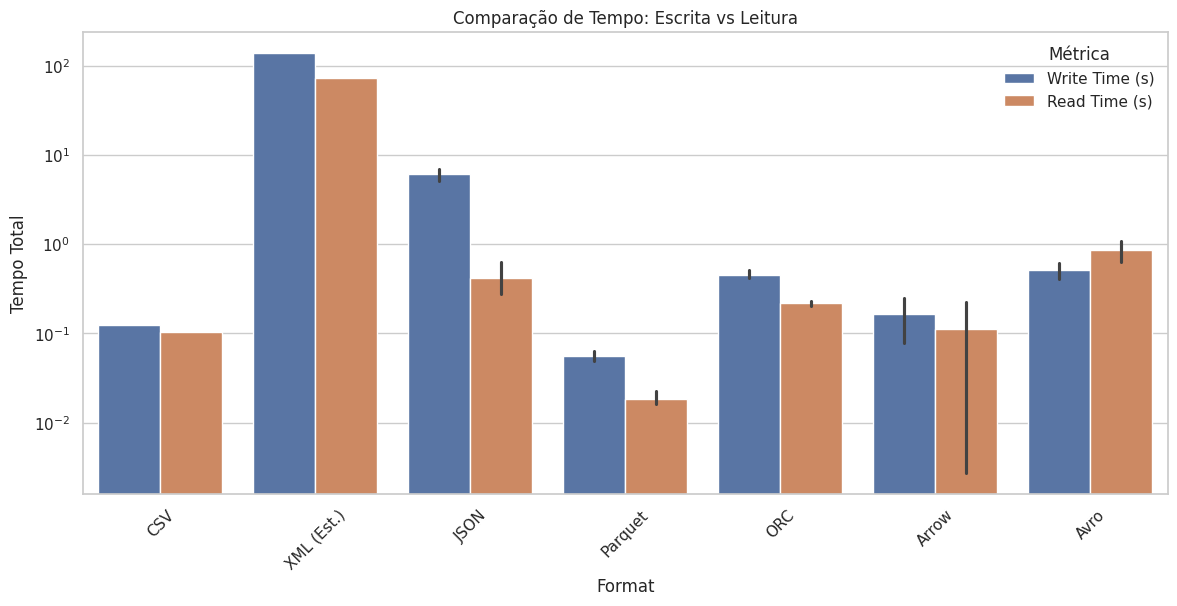

In [33]:
plt.figure(figsize=(14, 6))
metrics_df = df_final.melt(
    id_vars=["Format", "Compression"],
    value_vars=["Write Time (s)", "Read Time (s)"],
    var_name="Métrica",
    value_name="Tempo Total",
)
sns.barplot(data=metrics_df, x="Format", y="Tempo Total", hue="Métrica")
plt.title("Comparação de Tempo: Escrita vs Leitura")
plt.yscale("log")
plt.xticks(rotation=45)
plt.show()

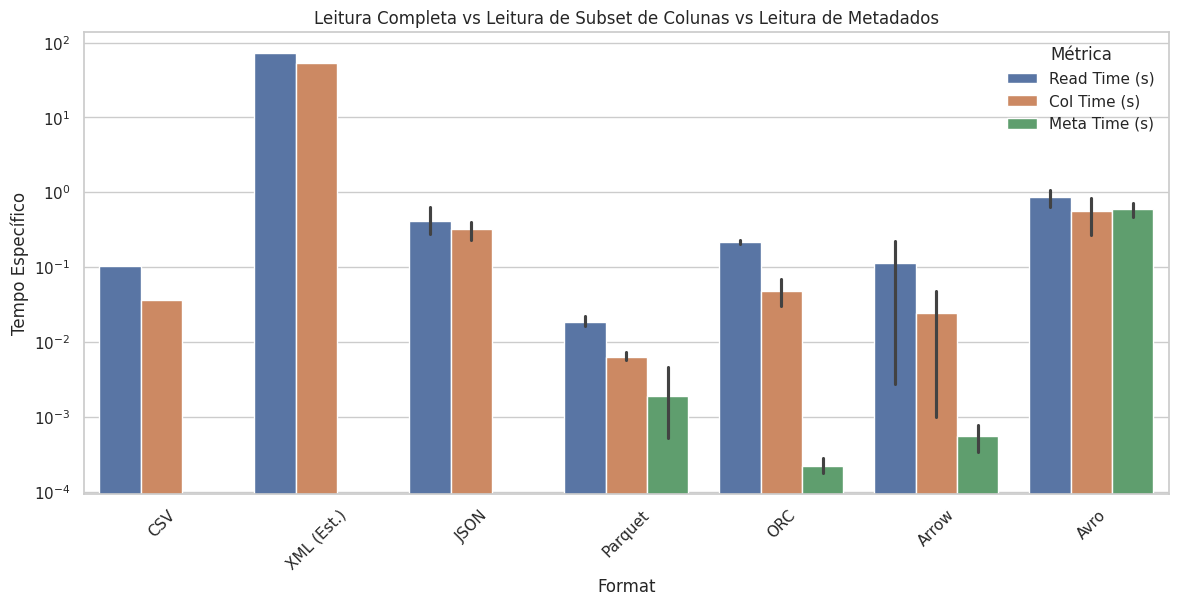

In [34]:
plt.figure(figsize=(14, 6))
read_metrics = df_final.melt(
    id_vars=["Format", "Compression"],
    value_vars=["Read Time (s)", "Col Time (s)", "Meta Time (s)"],
    var_name="Métrica",
    value_name="Tempo Específico",
)
sns.barplot(data=read_metrics, x="Format", y="Tempo Específico", hue="Métrica")
plt.title("Leitura Completa vs Leitura de Subset de Colunas vs Leitura de Metadados")
plt.yscale("log")
plt.xticks(rotation=45)
plt.show()

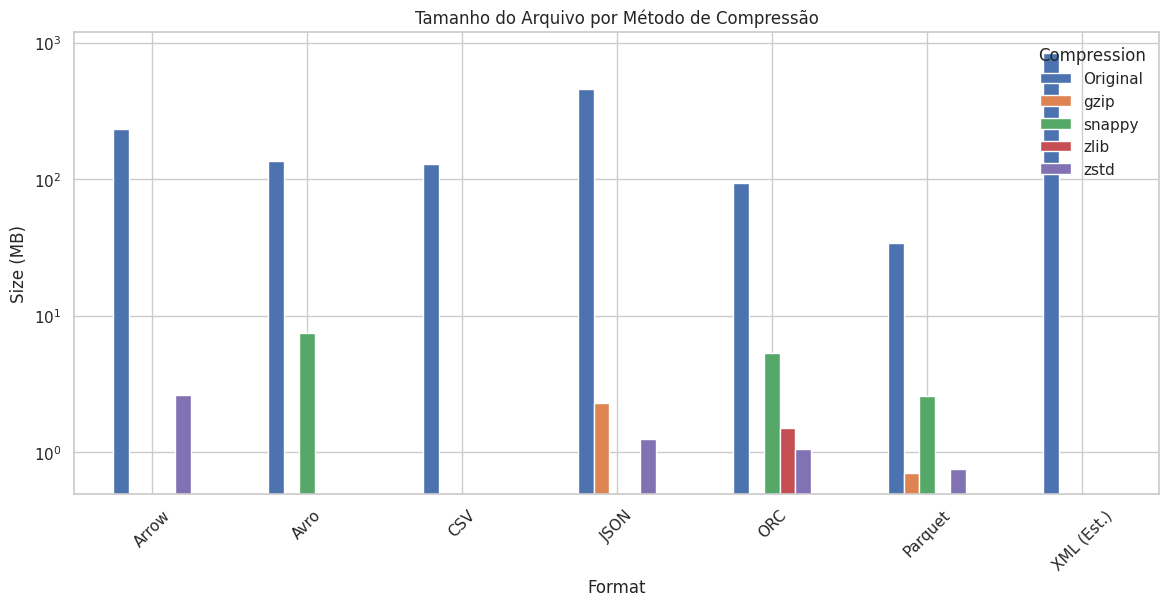

In [35]:
ax = df_final.pivot(index="Format", columns="Compression", values="Size (MB)").plot(
    kind="bar", figsize=(14, 6)
)
plt.title("Tamanho do Arquivo por Método de Compressão")
plt.ylabel("Size (MB)")
plt.yscale("log")
plt.xticks(rotation=45)
plt.show()

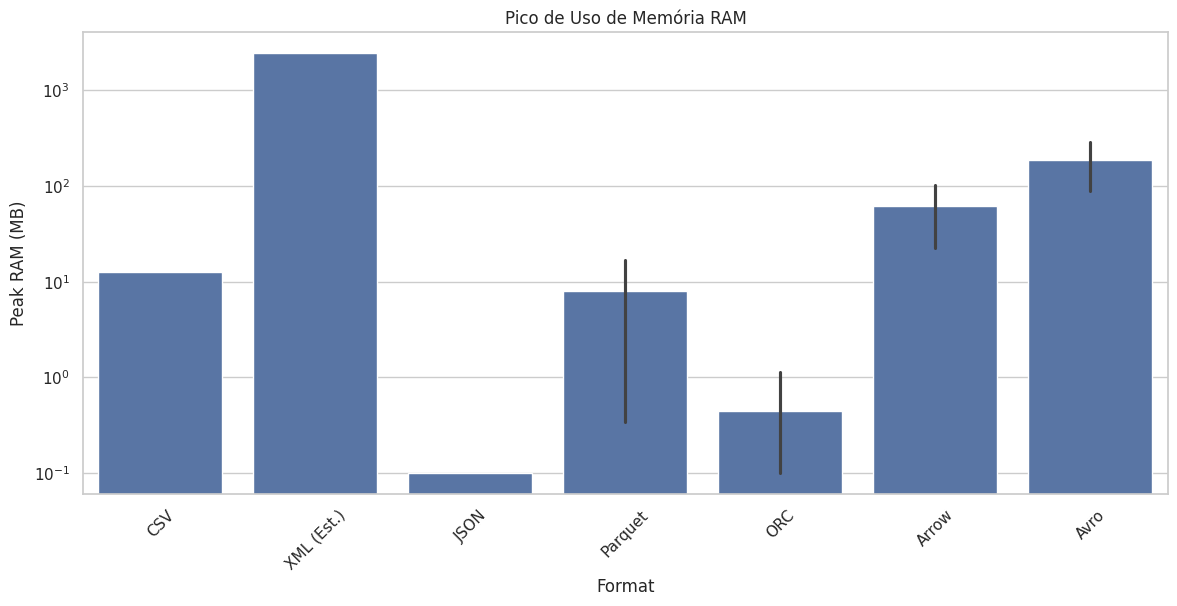

In [36]:
plt.figure(figsize=(14, 6))
sns.barplot(data=df_final, x="Format", y="Peak RAM (MB)")
plt.title("Pico de Uso de Memória RAM")
plt.yscale("log")
plt.xticks(rotation=45)
plt.show()

In [37]:
print(f"Tempo total de processamento: {time.time() - workflow_start:.2f}s")

Tempo total de processamento: 50.47s


### 6.5 Referências adicionais e nota de apoio

- **Parquet:** [Parquet File Format](https://parquet.apache.org/docs/file-format/) | [Parquet Concepts](https://parquet.apache.org/docs/concepts/)
- **ORC:** [ORC Spec v1](https://orc.apache.org/specification/ORCv1/) | [RCFile vs ORC](https://www.bigdatainrealworld.com/rcfile-vs-orc/)
- **Arrow:** [Arrow Columnar Format](https://arrow.apache.org/docs/format/Columnar.html)
- **Avro:** [Especificação Avro](https://avro.apache.org/docs/current/specification/)
- **Uso de IA:** Partes da consolidação teórica e da padronização de formatação deste notebook foram revisadas com apoio de IA generativa para checagem de clareza, consistência e fluidez do texto.


## 7. Apêndice Documental

Este apêndice reúne um resumo dos documentos que ajudam a entender o percurso do projeto, suas validações e os limites ainda presentes na versão atual.


### 7.1 Resumo da validacao de consonancia

A validacao consolidada concluiu que o repositorio esta **substancialmente conforme** ao `PROJETO DE PESQUISA DOIS`. Os pontos centrais desse resultado sao:

- adocao de uma leitura descritiva, comparativa e multicausal;
- cobertura das bases centrais (`populacao`, `PAM`, `PPM`, `Censo Agropecuario`, `INEP`);
- integracao territorial por `codigo_municipio` de 7 digitos;
- presenca de `matriculas_ensino_medio_rural_2024`, `taxa_abandono_rural_2024` e `regime_territorial`;
- execucao local da analise com validacoes internas consistentes.

As ressalvas restantes se concentram principalmente na documentacao de alto nivel e em limitacoes de cobertura. Na versao atual, a classificacao final deixa de usar `dados_insuficientes` como categoria generica e passa a separar lacuna estrutural de educacao rural e insuficiencia residual propriamente dita.